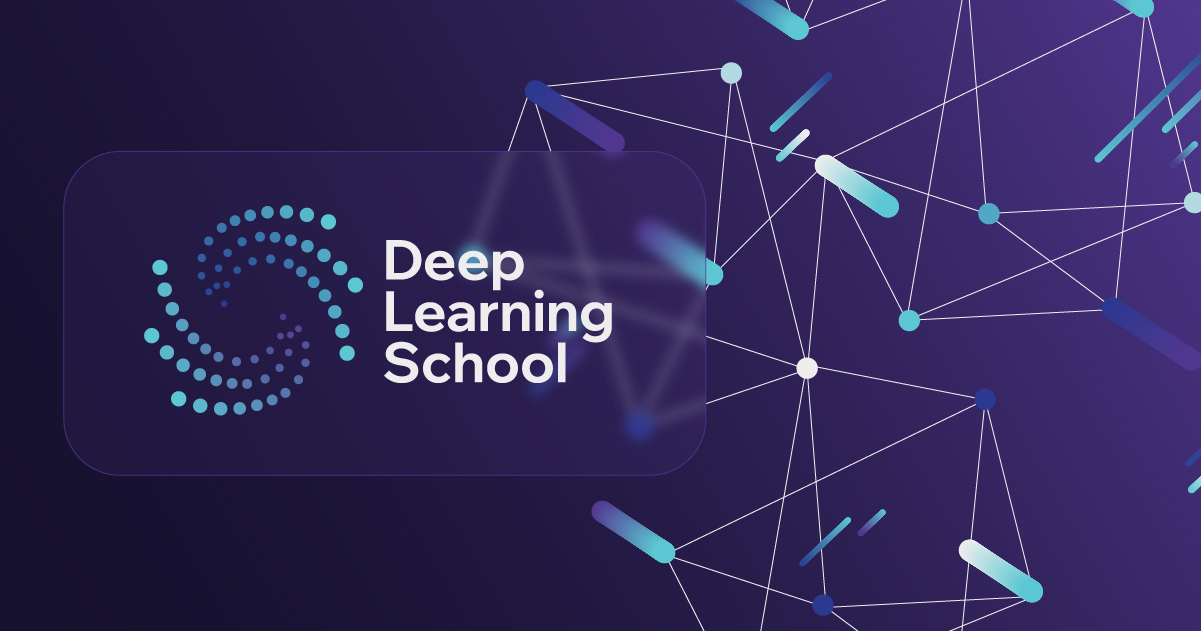


# Домашнее задание "Варианционные автоэнкодеры"

В этом домашнем задании вам предстоит реализовать несколько версий автоэнкодера для работы с изображениями.

Вы научитесь добавлять улыбку на фотографии людей, изменяя их исходное выражение лица с помощью обученной модели. А также, обучите ваш автоэнкодер генерировать изображения рукописных цифр.

# Часть 1. Vanilla Autoencoder (10 баллов)

## 1.1. Подготовка данных (1 балл)


Перед тем, как начинать работу с моделями нужно подготовить данные.

In [ ]:
import numpy as np
from torch.autograd import Variable
from torchvision import datasets
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
import torch
import matplotlib.pyplot as plt

import os
import pandas as pd
import skimage.io
from skimage.transform import resize

import imageio
from PIL import Image
import kagglehub

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import copy
import time

%matplotlib inline

В этом задании вам предстоить работать с датасетом [LFW (Labeled Faces in the Wild)](https://datasets.activeloop.ai/docs/ml/datasets/lfw-dataset/#:~:text=What%20is%20LFW%20Dataset%3F,commercial%20algorithms%20prior%20to%20release).

In [ ]:
# Скачиваем картинки
images_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
print("Path to dataset files:", images_path)

Using Colab cache for faster access to the 'lfw-dataset' dataset.
Path to dataset files: /kaggle/input/lfw-dataset


In [ ]:
# Скачиваем атрибуты
attrs_path = kagglehub.dataset_download("averkij/lfw-attributes")
print("Path to dataset files:", attrs_path)

Using Colab cache for faster access to the 'lfw-attributes' dataset.
Path to dataset files: /kaggle/input/lfw-attributes


In [ ]:
DATASET_PATH ="/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/"
ATTRIBUTES_PATH = "/kaggle/input/lfw-attributes/lfw_attributes.txt"

In [ ]:
def fetch_dataset(dx=80, dy=80, dimx=45, dimy=45):

    df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1,)
    df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns = df_attrs.columns[1:])

    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath, fname)
                photo_id = fname[:-4].replace('_', ' ').split()
                person_id = ' '.join(photo_id[:-1])
                photo_number = int(photo_id[-1])
                photo_ids.append({'person': person_id,'imagenum': photo_number, 'photo_path': fpath})

    photo_ids = pd.DataFrame(photo_ids)
    df = pd.merge(df_attrs,photo_ids,on=('person', 'imagenum'))

    assert len(df) == len(df_attrs), "Потеряны данные при объединении датафреймов!"

    images = df['photo_path'].apply(imageio.imread)\
                                .apply(lambda img:img[dy:-dy, dx:-dx])\
                                .apply(lambda img: np.array(Image.fromarray(img).resize([dimx, dimy])) )

    images = np.stack(images.values).astype('uint8')
    attrs = df.drop(["photo_path","person","imagenum"],axis=1)

    return images, attrs

In [ ]:
# Обратите внимание, что датасет представляет собой не только картинки, но и атрибуты
# Атрибуты понадобятся в конце этого задания

images, attrs = fetch_dataset()


Разбейте датасет изображений и атрибутов на train и val, выведите несколько картинок в output, чтобы посмотреть, как они выглядят, и приведите картинки к тензорам pytorch, чтобы можно было скормить их сети:

In [ ]:
train_idx, val_idx = train_test_split(
    np.arange(len(images)),
    test_size=0.2,
    random_state=42
)

train_images = images[train_idx]
val_images = images[val_idx]
train_attrs = attrs.iloc[train_idx]
val_attrs = attrs.iloc[val_idx]

print(f"Размер train: {len(train_images)} изображений")
print(f"Размер val: {len(val_images)} изображений")

Размер train: 10514 изображений
Размер val: 2629 изображений


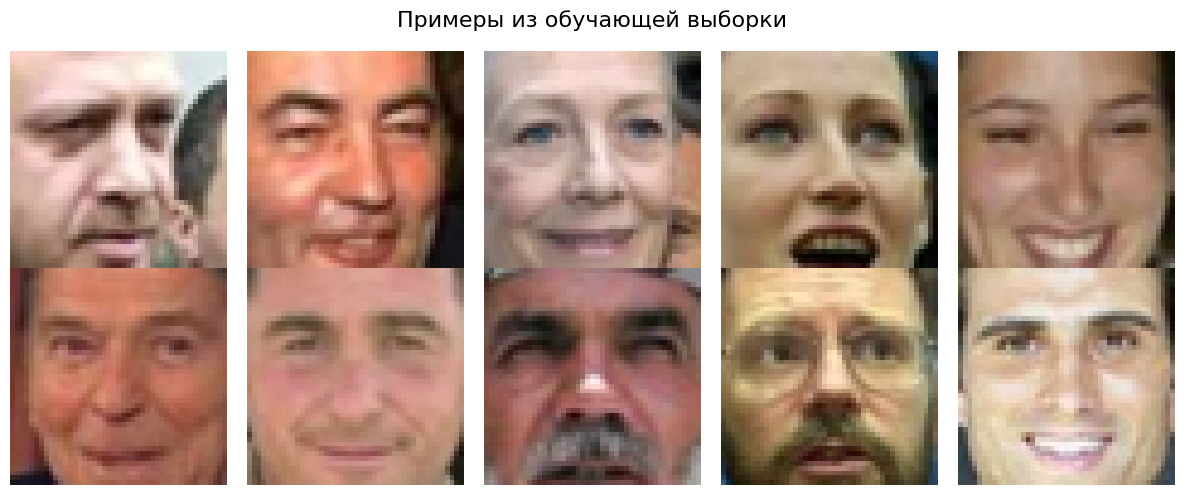

In [ ]:
#Вывод изображений для примера

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()
for i in range(10):
    axes[i].imshow(train_images[i])
    axes[i].axis('off')
plt.suptitle("Примеры из обучающей выборки", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
#Преображение изображения в тензоры PyTorch
train_tensor = torch.from_numpy(train_images).permute(0, 3, 1, 2).float() / 255.0
val_tensor = torch.from_numpy(val_images).permute(0, 3, 1, 2).float() / 255.0

print(f"Форма тензора train: {train_tensor.shape}")
print(f"Форма тензора val: {val_tensor.shape}")

Форма тензора train: torch.Size([10514, 3, 45, 45])
Форма тензора val: torch.Size([2629, 3, 45, 45])


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

# Текущая форма: (N, height, width, channels) -> нужно (N, channels, height, width)
# Также переводим из uint8 в float32 и нормализуем в диапазон [0, 1]

train_dataset = TensorDataset(train_tensor, train_tensor)
val_dataset   = TensorDataset(val_tensor, val_tensor)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)

## 1.2. Архитектура модели (2 балла)
В этом разделе вы напишите и обучите обычный автоэнкодер.



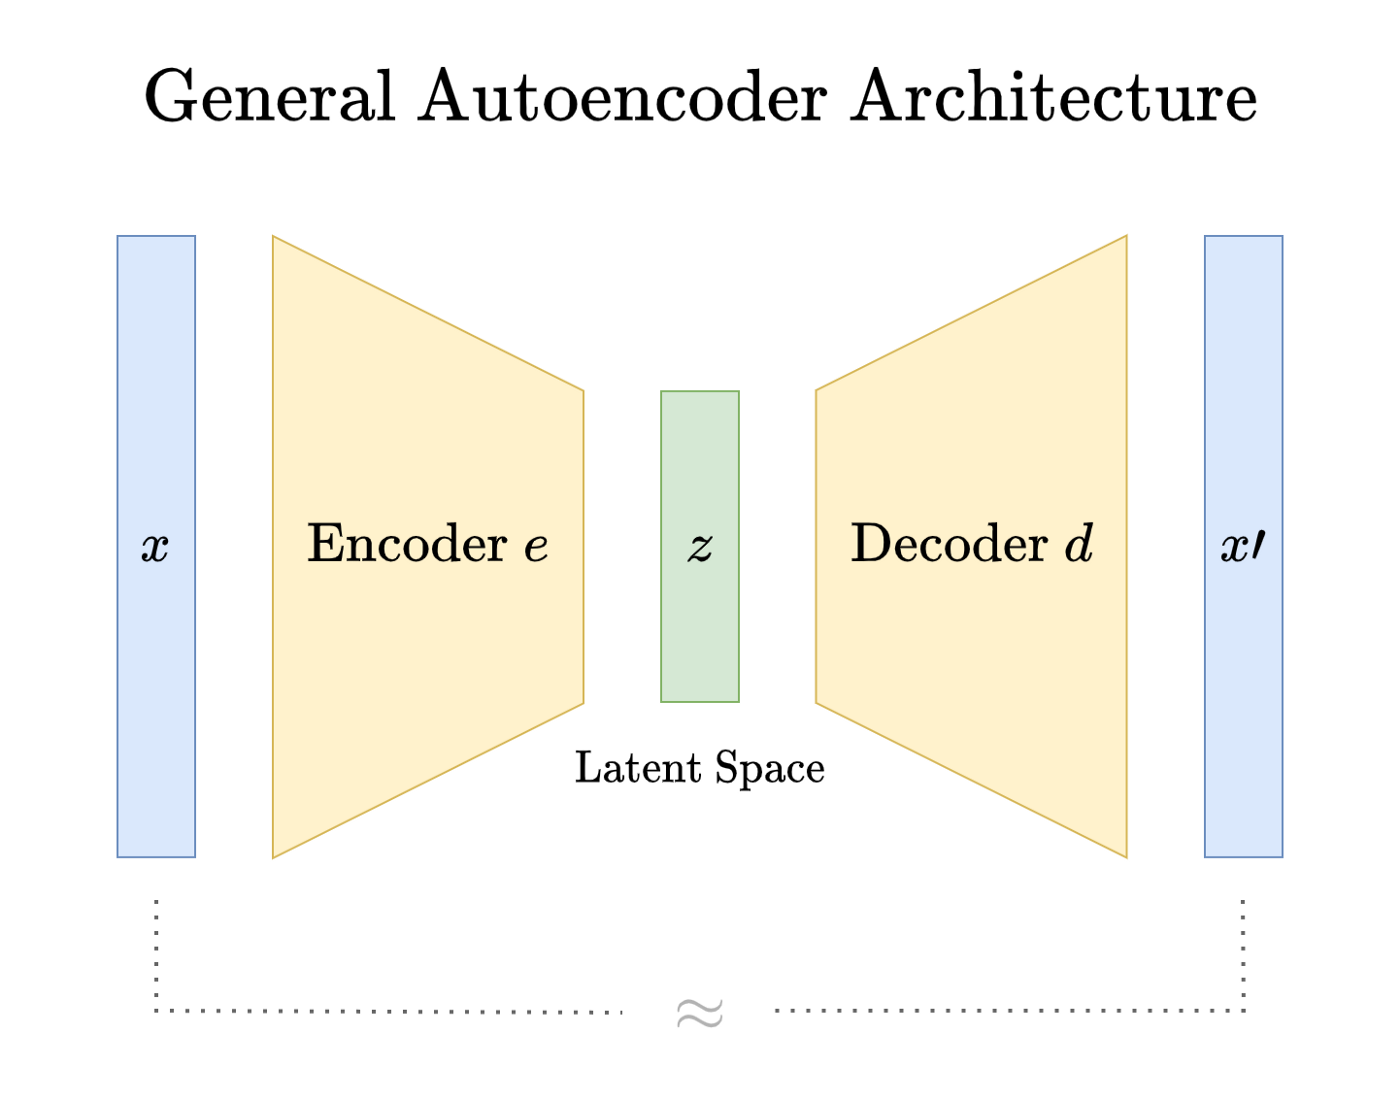

Реализуем autoencoder. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Экспериментируйте!

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=128):

        super(Autoencoder, self).__init__()
        self.latent_dim = latent_dim

        # Энкодер
        self.encoder = nn.Sequential(
            # вход: [batch, 3, 45, 45]
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),  # -> 32x23x23
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # -> 64x12x12
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),# -> 128x6x6
            nn.ReLU(inplace=True),
        )

        # размер после свёрток: 128 * 6 * 6 = 4608
        self.flatten_dim = 128 * 6 * 6

        self.fc_enc = nn.Linear(self.flatten_dim, latent_dim)

        # Декодер
        self.fc_dec = nn.Linear(latent_dim, self.flatten_dim)

        self.decoder = nn.Sequential(
            # блок 1: 128x6x6 -> Upsample -> 64x12x12
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),

            # блок 2: 64x12x12 -> Upsample -> 32x24x24
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),

            # блок 3: 32x24x24 -> Upsample -> 32x48x48
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),

            # финальная свёртка: 32x48x48 -> 3x45x45
            nn.Conv2d(32, 3, kernel_size=4, stride=1, padding=0),
            nn.Sigmoid()  # пиксели в [0,1]
        )

    def forward(self, x):

        # энкодер
        features = self.encoder(x)                # [batch, 128, 6, 6]
        flat = features.reshape(features.size(0), -1) # [batch, 4608]
        latent_code = self.fc_enc(flat)           # [batch, latent_dim]

        # декодер
        h = self.fc_dec(latent_code)              # [batch, 4608]
        h = h.reshape(-1, 128, 6, 6)                     # [batch, 128, 6, 6]
        reconstruction = self.decoder(h)          # [batch, 3, 45, 45]

        return reconstruction, latent_code

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

criterion = nn.MSELoss()

model = Autoencoder(latent_dim=256).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)

## 1.3 Обучение (2 балла)

Осталось написать код обучения автоэнкодера. При этом было бы неплохо в процессе иногда смотреть, как автоэнкодер реконструирует изображения на данном этапе обучения. Наример, после каждой эпохи (прогона train выборки через автоэнкодер) можно смотреть, какие реконструкции получились для каких-то изображений val выборки.

А, ну еще было бы неплохо выводить графики train и val лоссов в процессе тренировки =)

In [ ]:
def train_autoencoder(model, optimizer, criterion, train_loader, val_loader,
                      num_epochs, patience, device, scheduler=None, vis_interval=5):

    model = model.to(device)
    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_wts = None

    # фиксируем фиксированный набор изображений для визуализации
    # берём один батч из валидации
    sample_batch, _ = next(iter(val_loader))
    sample_img = sample_batch[:8].to(device)  # до 8 картинок для сетки

    for epoch in range(1, num_epochs + 1):
        start_time = time.time()

        # Обучение
        model.train()
        train_loss = 0.0
        for x, _ in train_loader:
            x = x.to(device)
            optimizer.zero_grad()
            reconstruction, _ = model(x)
            loss = criterion(reconstruction, x)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * x.size(0)

        train_loss /= len(train_loader.dataset)

        # Валидация
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(device)
                reconstruction, _ = model(x)
                loss = criterion(reconstruction, x)
                val_loss += loss.item() * x.size(0)

        val_loss /= len(val_loader.dataset)

        # сохраняем историю
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        # вывод результатов эпохи
        epoch_time = time.time() - start_time
        print(f"Epoch {epoch:3d}/{num_epochs} | Time: {epoch_time:5.1f}s | "
              f"Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}", end="")

        # планировщик
        if scheduler is not None:

            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        # Раняя остановка
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            best_model_wts = copy.deepcopy(model.state_dict())
            print("  << Лучшая модель сохранена >>")
        else:
            epochs_no_improve += 1
            print(f"  (Нет улучшений {epochs_no_improve}/{patience})")
            if epochs_no_improve >= patience:
                print(f"\nEarly stopping на эпохе {epoch}!")
                break

        # Визуализация
        if epoch % vis_interval == 0 or epoch == 1:
            model.eval()
            with torch.no_grad():
                recon_sample, _ = model(sample_img)

            # Переводим тензоры в numpy и масштабируем в [0,1]
            origin = sample_img.cpu().permute(0,2,3,1).numpy()
            recon = recon_sample.cpu().permute(0,2,3,1).numpy()

            n = min(len(origin), 8)
            fig, axes = plt.subplots(2, n, figsize=(2*n, 4))
            for i in range(n):
                axes[0,i].imshow(origin[i])
                axes[0,i].axis('off')
                axes[1,i].imshow(recon[i])
                axes[1,i].axis('off')
            axes[0,0].set_title('Original', fontsize=10)
            axes[1,0].set_title('Reconstructed', fontsize=10)
            plt.suptitle(f'Эпоха {epoch}', fontsize=14)
            plt.tight_layout()
            plt.show()

    # Загружаем веса лучшей модели перед возвратом
    if best_model_wts is not None:
        model.load_state_dict(best_model_wts)

    return model, history

Epoch   1/250 | Time:   3.9s | Train Loss: 0.016700 | Val Loss: 0.009173  << Лучшая модель сохранена >>


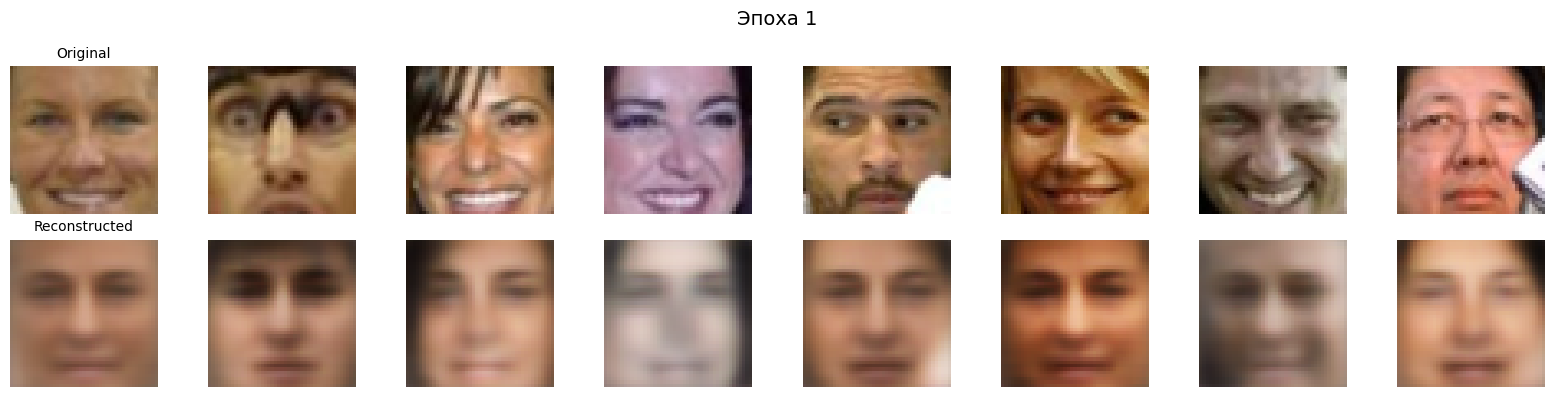

Epoch   2/250 | Time:   2.4s | Train Loss: 0.007167 | Val Loss: 0.005919  << Лучшая модель сохранена >>
Epoch   3/250 | Time:   2.5s | Train Loss: 0.005094 | Val Loss: 0.004940  << Лучшая модель сохранена >>
Epoch   4/250 | Time:   2.4s | Train Loss: 0.004219 | Val Loss: 0.003901  << Лучшая модель сохранена >>
Epoch   5/250 | Time:   2.4s | Train Loss: 0.003616 | Val Loss: 0.003543  << Лучшая модель сохранена >>


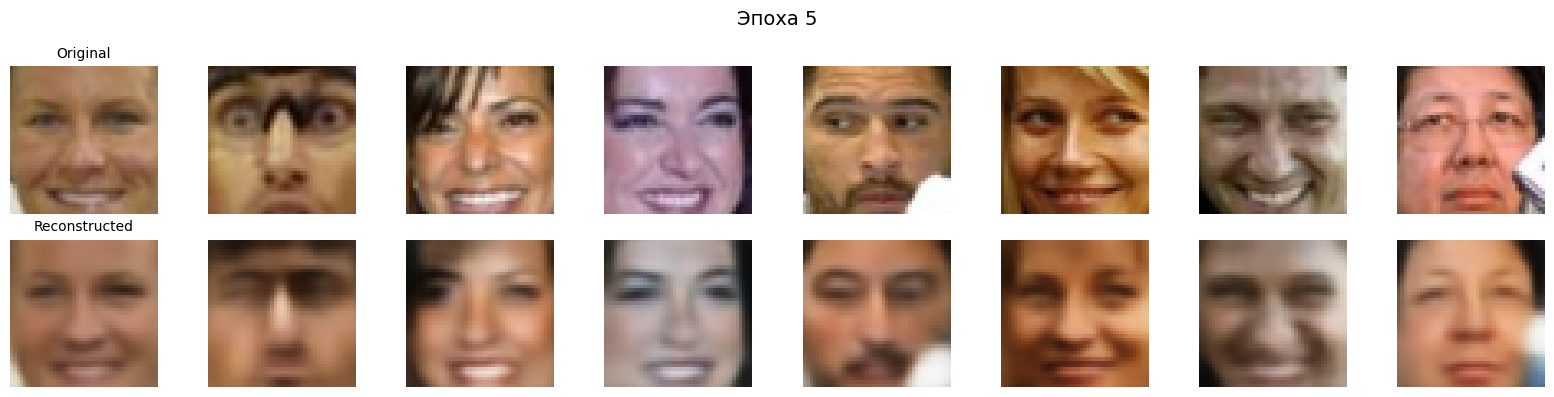

Epoch   6/250 | Time:   2.4s | Train Loss: 0.003298 | Val Loss: 0.003164  << Лучшая модель сохранена >>
Epoch   7/250 | Time:   2.4s | Train Loss: 0.002930 | Val Loss: 0.002811  << Лучшая модель сохранена >>
Epoch   8/250 | Time:   2.5s | Train Loss: 0.002634 | Val Loss: 0.002638  << Лучшая модель сохранена >>
Epoch   9/250 | Time:   2.4s | Train Loss: 0.002472 | Val Loss: 0.002549  << Лучшая модель сохранена >>
Epoch  10/250 | Time:   2.4s | Train Loss: 0.002282 | Val Loss: 0.002398  << Лучшая модель сохранена >>


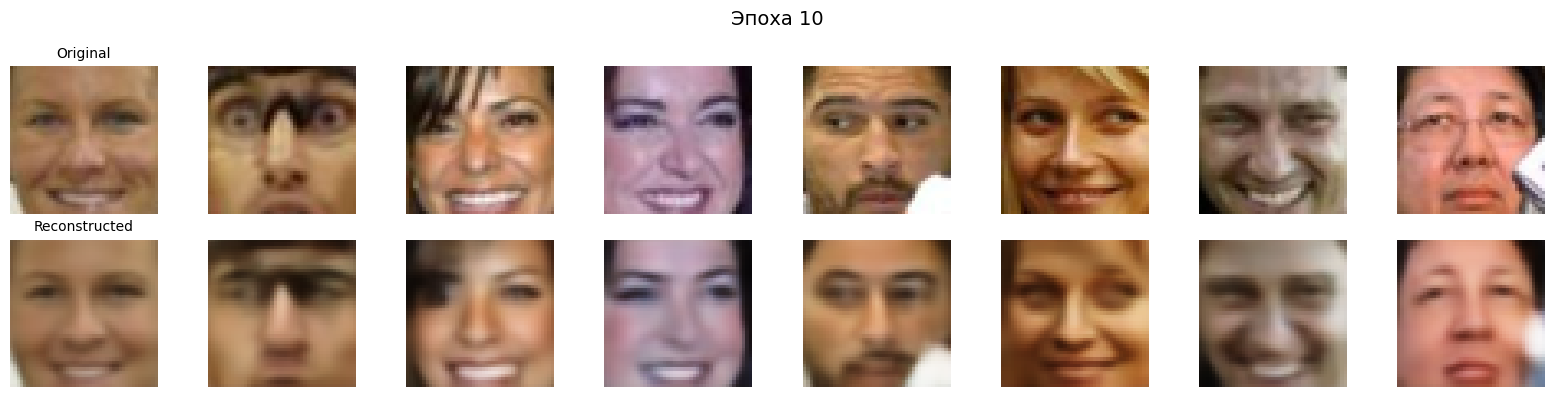

Epoch  11/250 | Time:   2.4s | Train Loss: 0.002193 | Val Loss: 0.002280  << Лучшая модель сохранена >>
Epoch  12/250 | Time:   2.4s | Train Loss: 0.002075 | Val Loss: 0.002230  << Лучшая модель сохранена >>
Epoch  13/250 | Time:   2.5s | Train Loss: 0.001966 | Val Loss: 0.002083  << Лучшая модель сохранена >>
Epoch  14/250 | Time:   2.4s | Train Loss: 0.001867 | Val Loss: 0.001972  << Лучшая модель сохранена >>
Epoch  15/250 | Time:   2.4s | Train Loss: 0.001803 | Val Loss: 0.001872  << Лучшая модель сохранена >>


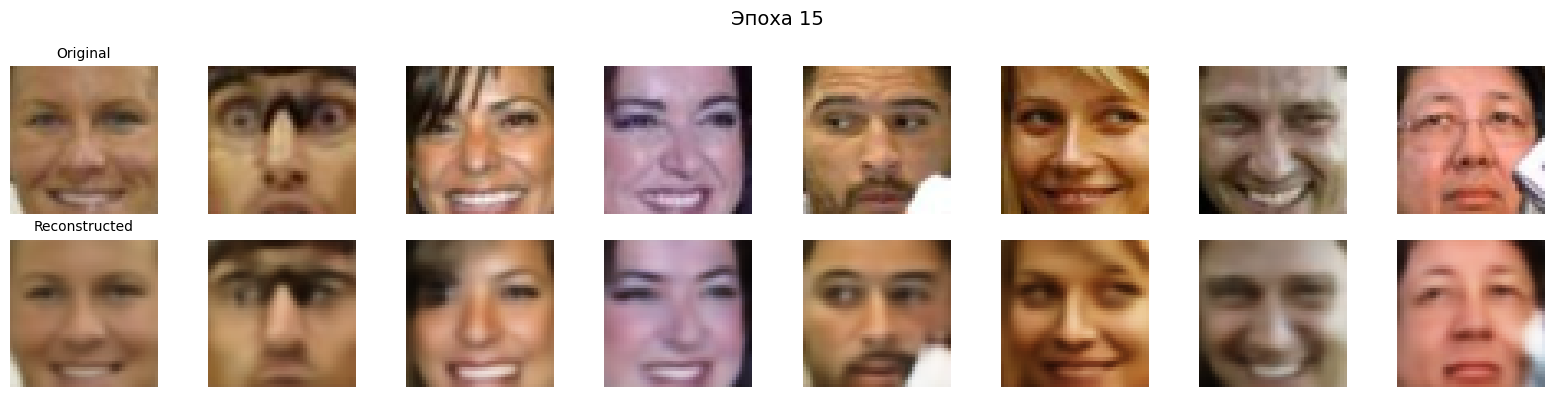

Epoch  16/250 | Time:   2.4s | Train Loss: 0.001718 | Val Loss: 0.001929  (Нет улучшений 1/50)
Epoch  17/250 | Time:   2.4s | Train Loss: 0.001675 | Val Loss: 0.001773  << Лучшая модель сохранена >>
Epoch  18/250 | Time:   2.5s | Train Loss: 0.001584 | Val Loss: 0.001812  (Нет улучшений 1/50)
Epoch  19/250 | Time:   2.4s | Train Loss: 0.001567 | Val Loss: 0.001693  << Лучшая модель сохранена >>
Epoch  20/250 | Time:   2.4s | Train Loss: 0.001516 | Val Loss: 0.001811  (Нет улучшений 1/50)


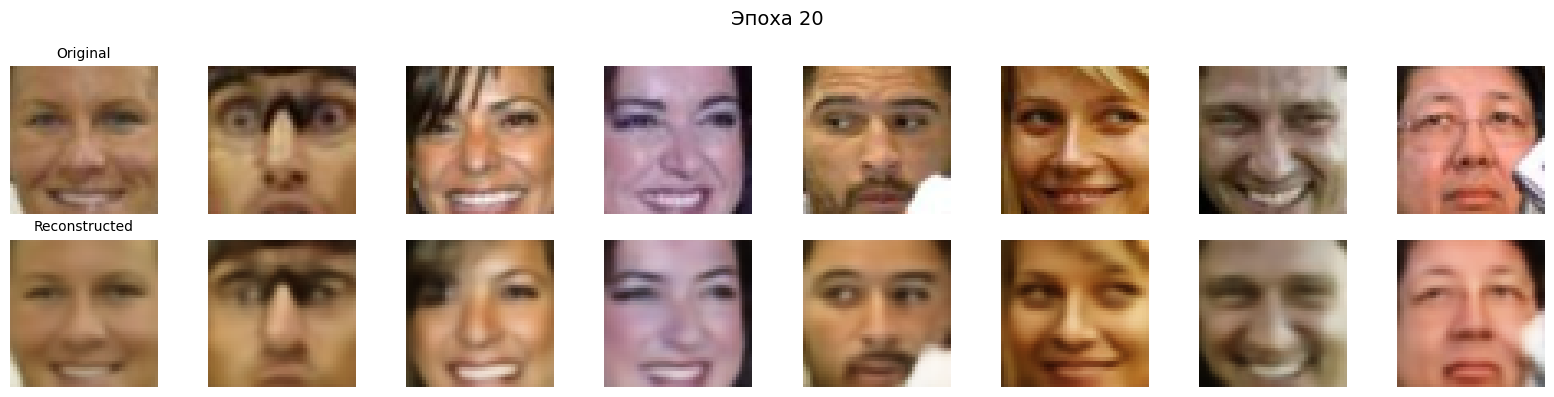

Epoch  21/250 | Time:   2.4s | Train Loss: 0.001451 | Val Loss: 0.001605  << Лучшая модель сохранена >>
Epoch  22/250 | Time:   2.4s | Train Loss: 0.001409 | Val Loss: 0.001649  (Нет улучшений 1/50)
Epoch  23/250 | Time:   2.6s | Train Loss: 0.001394 | Val Loss: 0.001546  << Лучшая модель сохранена >>
Epoch  24/250 | Time:   2.4s | Train Loss: 0.001354 | Val Loss: 0.001645  (Нет улучшений 1/50)
Epoch  25/250 | Time:   2.4s | Train Loss: 0.001357 | Val Loss: 0.001516  << Лучшая модель сохранена >>


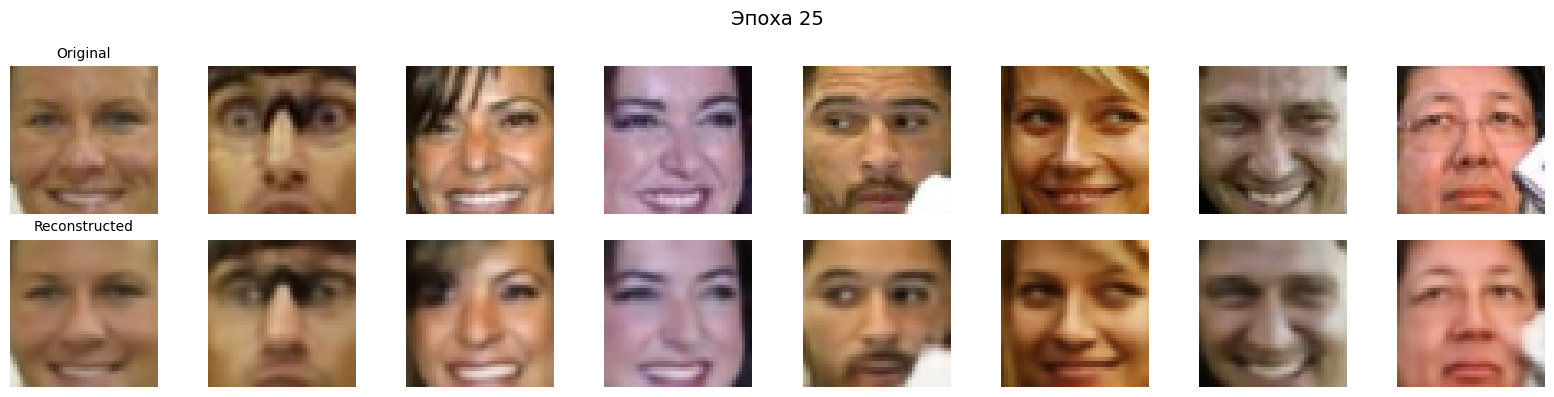

Epoch  26/250 | Time:   2.4s | Train Loss: 0.001270 | Val Loss: 0.001488  << Лучшая модель сохранена >>
Epoch  27/250 | Time:   2.5s | Train Loss: 0.001273 | Val Loss: 0.001497  (Нет улучшений 1/50)
Epoch  28/250 | Time:   2.5s | Train Loss: 0.001255 | Val Loss: 0.001432  << Лучшая модель сохранена >>
Epoch  29/250 | Time:   2.4s | Train Loss: 0.001242 | Val Loss: 0.001437  (Нет улучшений 1/50)
Epoch  30/250 | Time:   2.4s | Train Loss: 0.001196 | Val Loss: 0.001533  (Нет улучшений 2/50)


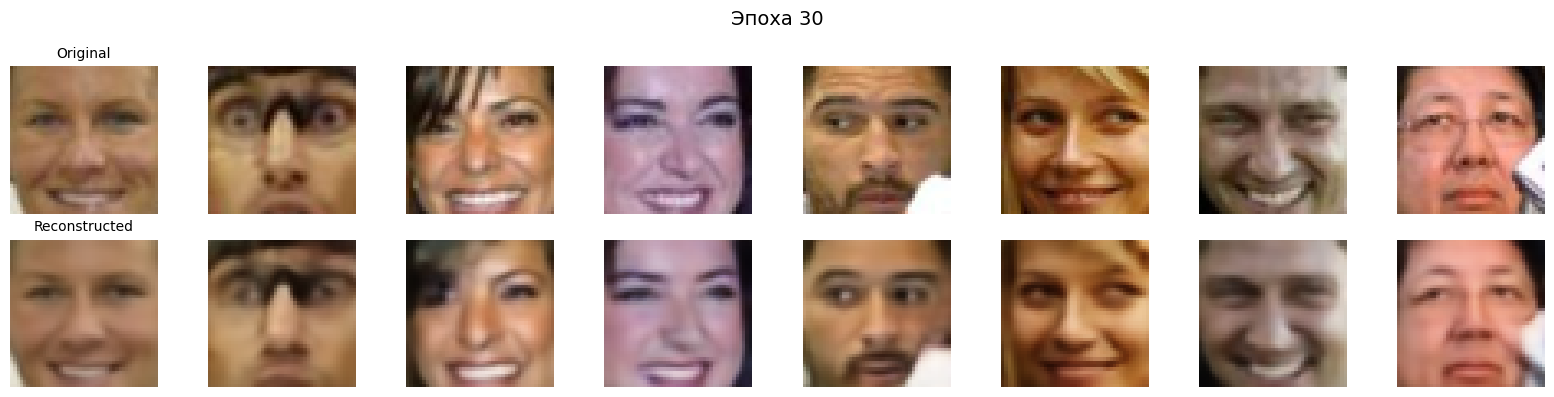

Epoch  31/250 | Time:   2.4s | Train Loss: 0.001189 | Val Loss: 0.001558  (Нет улучшений 3/50)
Epoch  32/250 | Time:   2.5s | Train Loss: 0.001151 | Val Loss: 0.001363  << Лучшая модель сохранена >>
Epoch  33/250 | Time:   2.5s | Train Loss: 0.001135 | Val Loss: 0.001391  (Нет улучшений 1/50)
Epoch  34/250 | Time:   2.4s | Train Loss: 0.001150 | Val Loss: 0.001351  << Лучшая модель сохранена >>
Epoch  35/250 | Time:   2.4s | Train Loss: 0.001094 | Val Loss: 0.001388  (Нет улучшений 1/50)


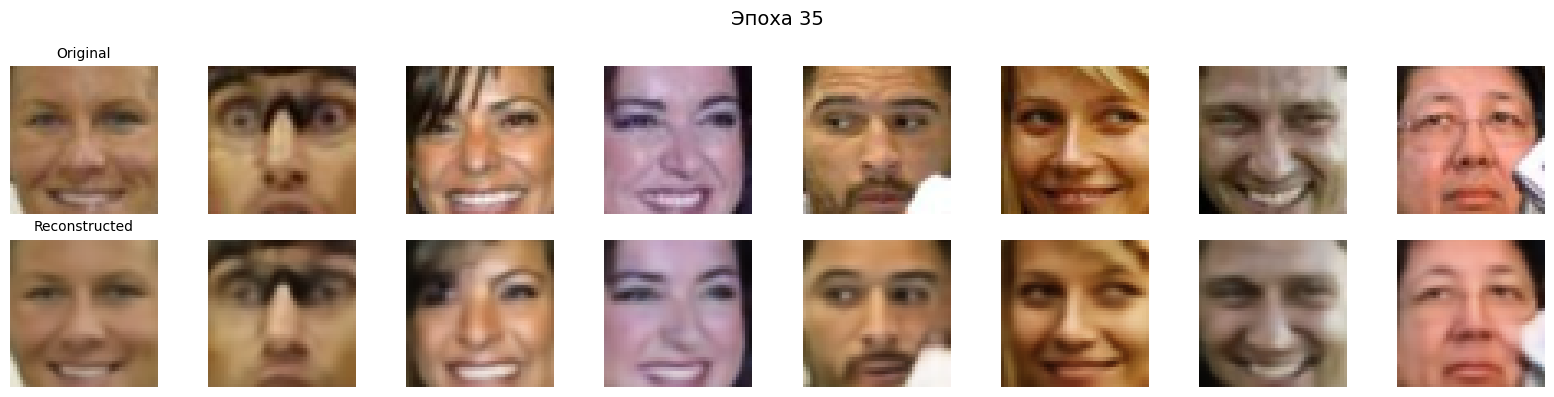

Epoch  36/250 | Time:   2.4s | Train Loss: 0.001114 | Val Loss: 0.001337  << Лучшая модель сохранена >>
Epoch  37/250 | Time:   2.5s | Train Loss: 0.001078 | Val Loss: 0.001380  (Нет улучшений 1/50)
Epoch  38/250 | Time:   2.6s | Train Loss: 0.001076 | Val Loss: 0.001419  (Нет улучшений 2/50)
Epoch  39/250 | Time:   2.4s | Train Loss: 0.001055 | Val Loss: 0.001450  (Нет улучшений 3/50)
Epoch  40/250 | Time:   2.4s | Train Loss: 0.001052 | Val Loss: 0.001309  << Лучшая модель сохранена >>


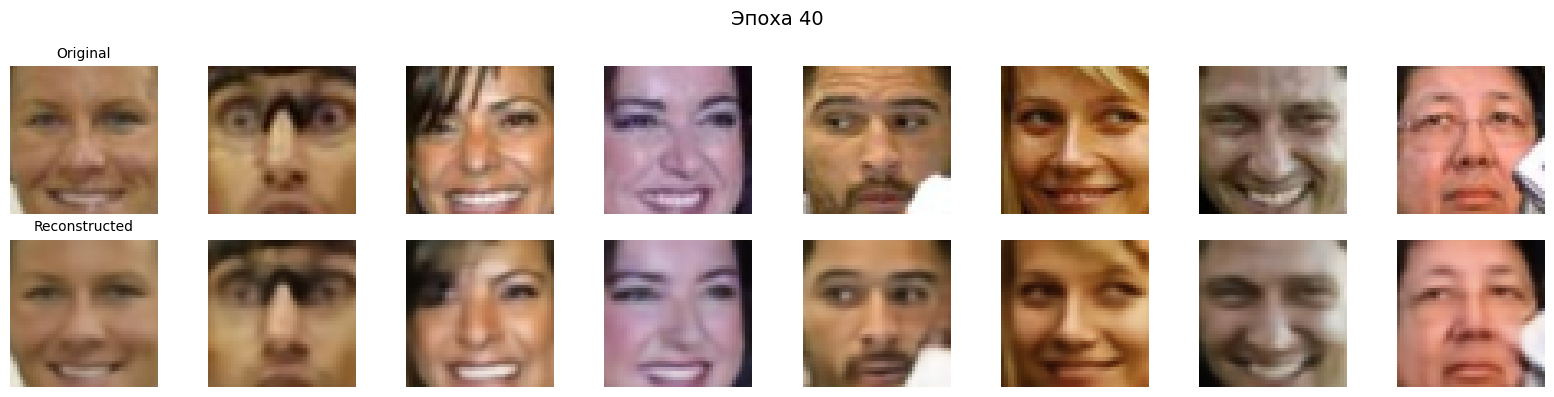

Epoch  41/250 | Time:   2.4s | Train Loss: 0.001039 | Val Loss: 0.001333  (Нет улучшений 1/50)
Epoch  42/250 | Time:   2.5s | Train Loss: 0.001015 | Val Loss: 0.001299  << Лучшая модель сохранена >>
Epoch  43/250 | Time:   2.5s | Train Loss: 0.001000 | Val Loss: 0.001319  (Нет улучшений 1/50)
Epoch  44/250 | Time:   2.4s | Train Loss: 0.001015 | Val Loss: 0.001308  (Нет улучшений 2/50)
Epoch  45/250 | Time:   2.4s | Train Loss: 0.000987 | Val Loss: 0.001366  (Нет улучшений 3/50)


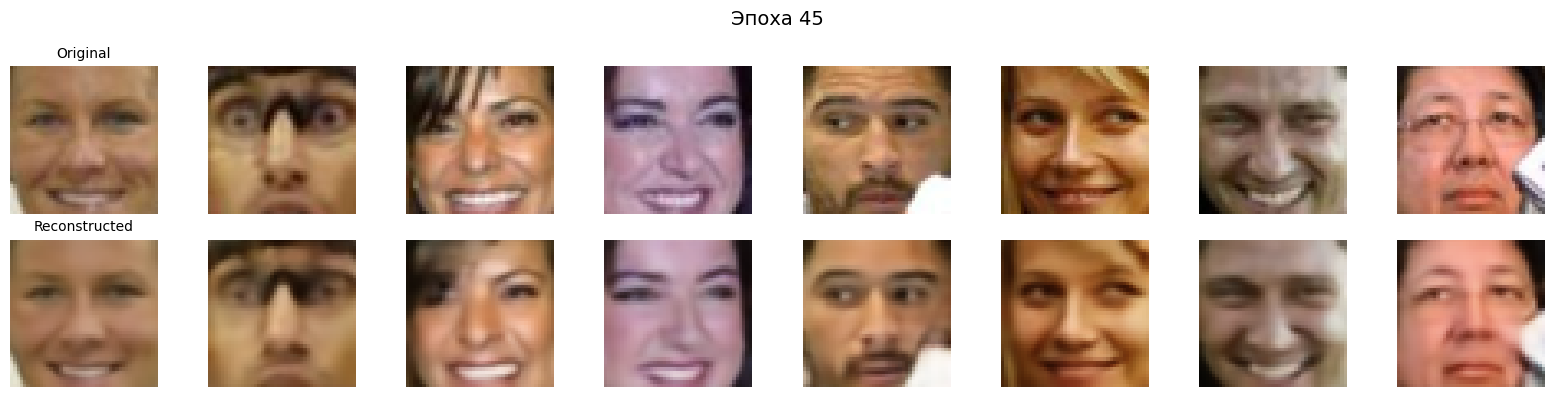

Epoch  46/250 | Time:   2.4s | Train Loss: 0.000990 | Val Loss: 0.001312  (Нет улучшений 4/50)
Epoch  47/250 | Time:   2.5s | Train Loss: 0.000977 | Val Loss: 0.001395  (Нет улучшений 5/50)
Epoch  48/250 | Time:   2.5s | Train Loss: 0.000962 | Val Loss: 0.001303  (Нет улучшений 6/50)
Epoch  49/250 | Time:   2.4s | Train Loss: 0.000961 | Val Loss: 0.001261  << Лучшая модель сохранена >>
Epoch  50/250 | Time:   2.4s | Train Loss: 0.000954 | Val Loss: 0.001264  (Нет улучшений 1/50)


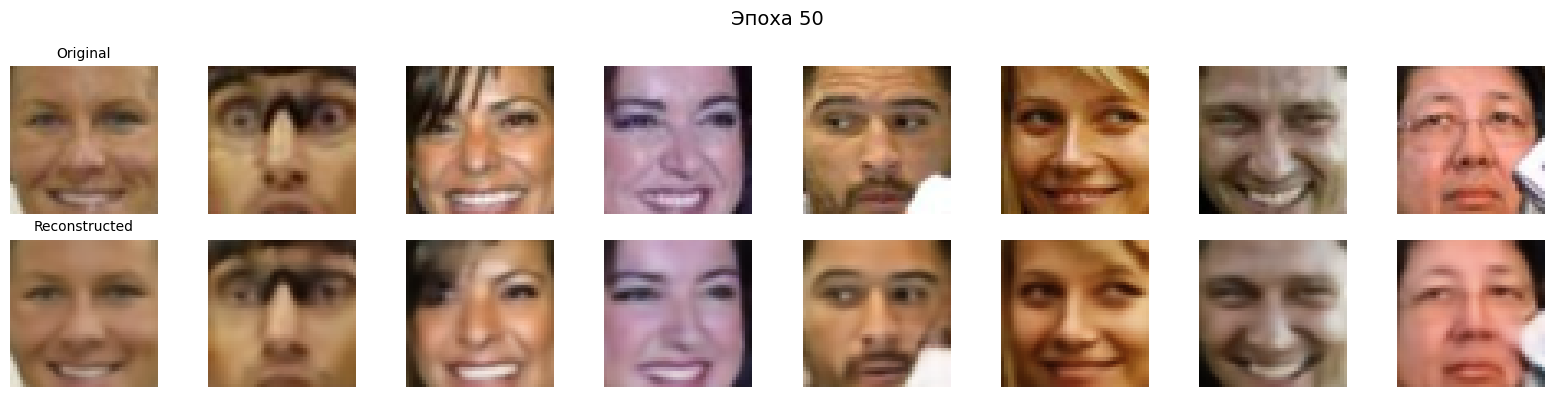

Epoch  51/250 | Time:   2.5s | Train Loss: 0.000949 | Val Loss: 0.001266  (Нет улучшений 2/50)
Epoch  52/250 | Time:   2.6s | Train Loss: 0.000954 | Val Loss: 0.001257  << Лучшая модель сохранена >>
Epoch  53/250 | Time:   2.5s | Train Loss: 0.000915 | Val Loss: 0.001318  (Нет улучшений 1/50)
Epoch  54/250 | Time:   2.4s | Train Loss: 0.000953 | Val Loss: 0.001316  (Нет улучшений 2/50)
Epoch  55/250 | Time:   2.4s | Train Loss: 0.000911 | Val Loss: 0.001251  << Лучшая модель сохранена >>


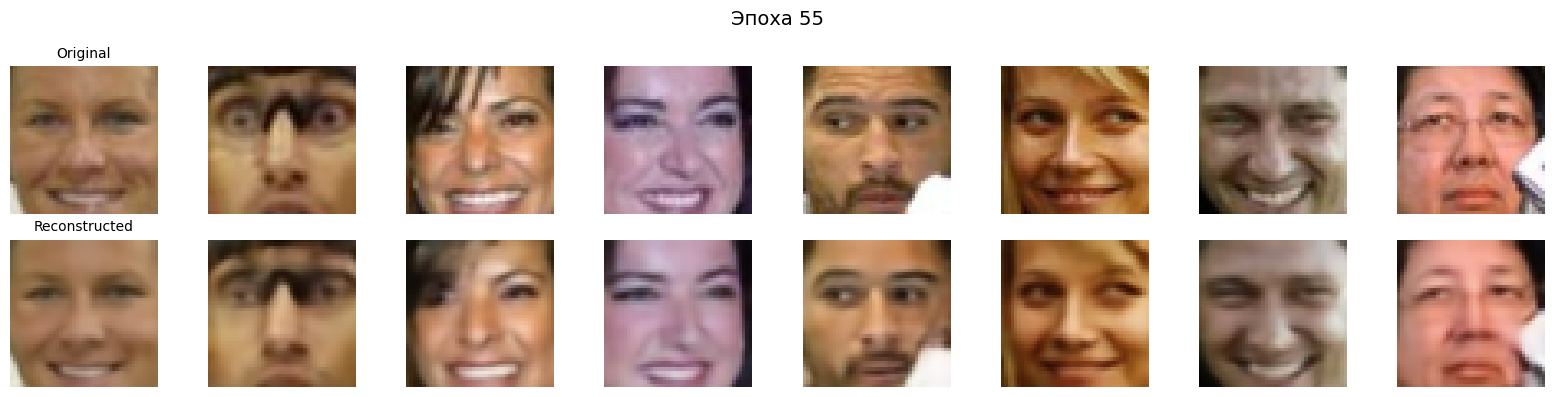

Epoch  56/250 | Time:   2.4s | Train Loss: 0.000890 | Val Loss: 0.001362  (Нет улучшений 1/50)
Epoch  57/250 | Time:   2.6s | Train Loss: 0.000937 | Val Loss: 0.001235  << Лучшая модель сохранена >>
Epoch  58/250 | Time:   2.5s | Train Loss: 0.000908 | Val Loss: 0.001279  (Нет улучшений 1/50)
Epoch  59/250 | Time:   2.5s | Train Loss: 0.000873 | Val Loss: 0.001290  (Нет улучшений 2/50)
Epoch  60/250 | Time:   2.5s | Train Loss: 0.000897 | Val Loss: 0.001256  (Нет улучшений 3/50)


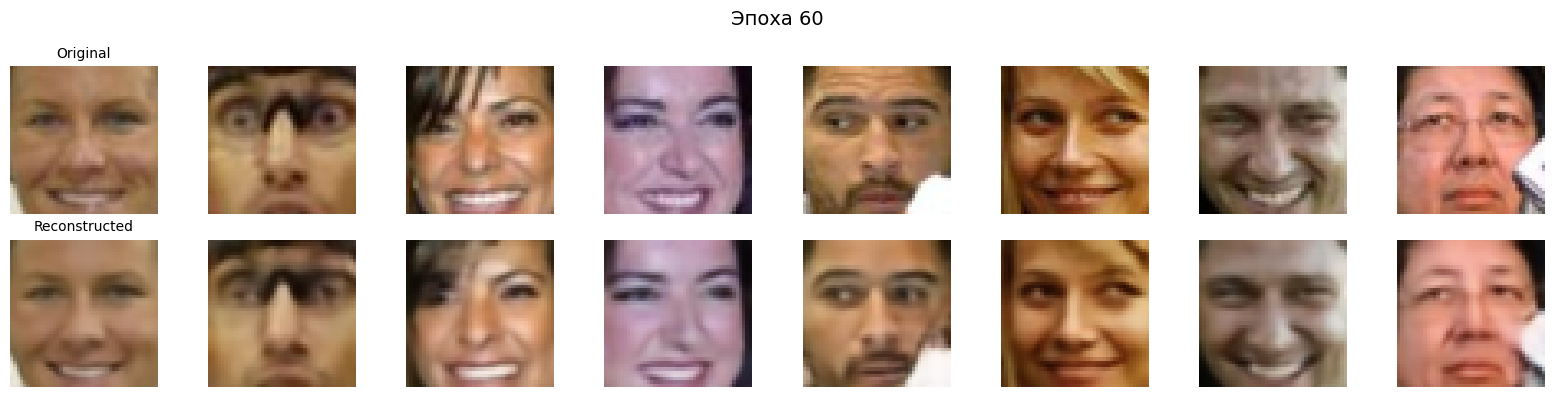

Epoch  61/250 | Time:   2.5s | Train Loss: 0.000901 | Val Loss: 0.001238  (Нет улучшений 4/50)
Epoch  62/250 | Time:   2.6s | Train Loss: 0.000874 | Val Loss: 0.001290  (Нет улучшений 5/50)
Epoch  63/250 | Time:   2.5s | Train Loss: 0.000900 | Val Loss: 0.001242  (Нет улучшений 6/50)
Epoch  64/250 | Time:   2.5s | Train Loss: 0.000842 | Val Loss: 0.001224  << Лучшая модель сохранена >>
Epoch  65/250 | Time:   2.5s | Train Loss: 0.000948 | Val Loss: 0.001256  (Нет улучшений 1/50)


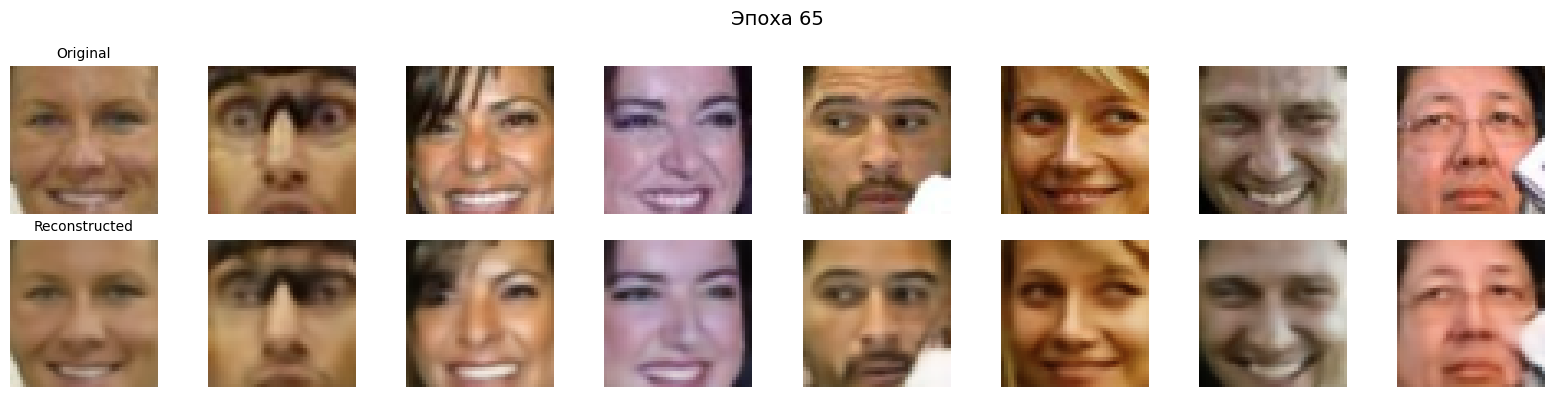

Epoch  66/250 | Time:   2.5s | Train Loss: 0.000836 | Val Loss: 0.001281  (Нет улучшений 2/50)
Epoch  67/250 | Time:   2.6s | Train Loss: 0.000833 | Val Loss: 0.001226  (Нет улучшений 3/50)
Epoch  68/250 | Time:   2.5s | Train Loss: 0.000851 | Val Loss: 0.001250  (Нет улучшений 4/50)
Epoch  69/250 | Time:   2.5s | Train Loss: 0.000866 | Val Loss: 0.001327  (Нет улучшений 5/50)
Epoch  70/250 | Time:   2.5s | Train Loss: 0.000840 | Val Loss: 0.001240  (Нет улучшений 6/50)


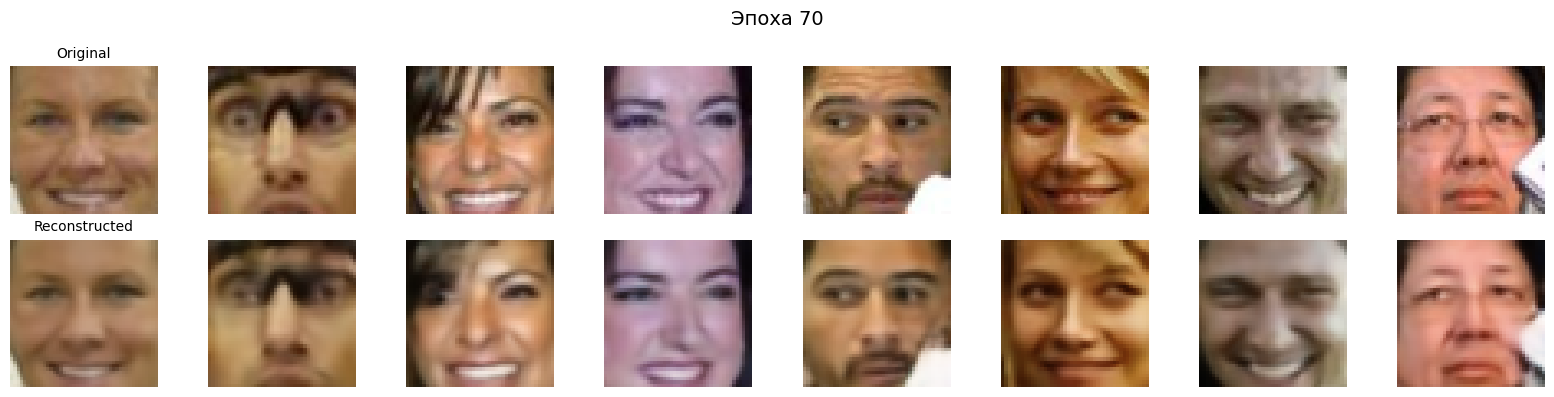

Epoch  71/250 | Time:   2.5s | Train Loss: 0.000849 | Val Loss: 0.001288  (Нет улучшений 7/50)
Epoch  72/250 | Time:   2.5s | Train Loss: 0.000821 | Val Loss: 0.001355  (Нет улучшений 8/50)
Epoch  73/250 | Time:   2.5s | Train Loss: 0.000827 | Val Loss: 0.001240  (Нет улучшений 9/50)
Epoch  74/250 | Time:   2.5s | Train Loss: 0.000841 | Val Loss: 0.001360  (Нет улучшений 10/50)
Epoch  75/250 | Time:   2.5s | Train Loss: 0.000831 | Val Loss: 0.001238  (Нет улучшений 11/50)


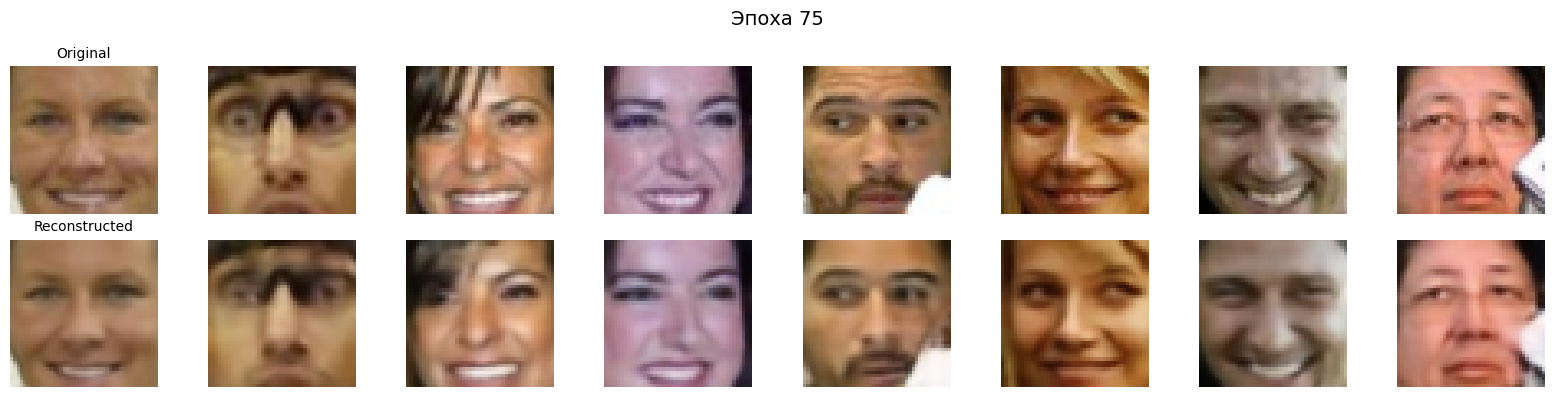

Epoch  76/250 | Time:   2.6s | Train Loss: 0.000808 | Val Loss: 0.001388  (Нет улучшений 12/50)
Epoch  77/250 | Time:   2.5s | Train Loss: 0.000843 | Val Loss: 0.001231  (Нет улучшений 13/50)
Epoch  78/250 | Time:   2.5s | Train Loss: 0.000812 | Val Loss: 0.001260  (Нет улучшений 14/50)
Epoch  79/250 | Time:   2.5s | Train Loss: 0.000808 | Val Loss: 0.001379  (Нет улучшений 15/50)
Epoch  80/250 | Time:   2.5s | Train Loss: 0.000805 | Val Loss: 0.001233  (Нет улучшений 16/50)


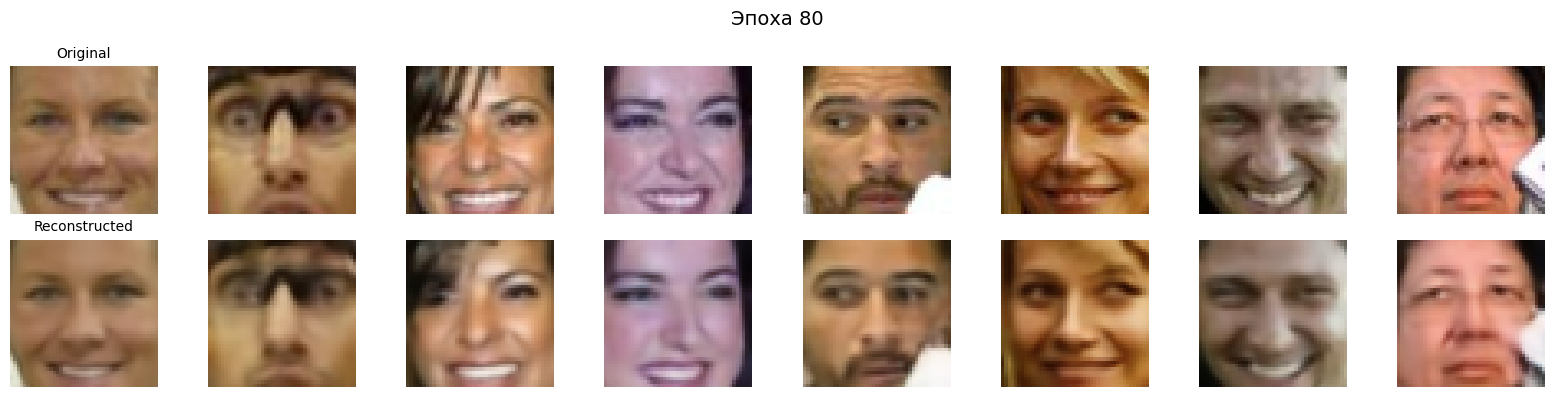

Epoch  81/250 | Time:   2.6s | Train Loss: 0.000819 | Val Loss: 0.001241  (Нет улучшений 17/50)
Epoch  82/250 | Time:   2.5s | Train Loss: 0.000795 | Val Loss: 0.001232  (Нет улучшений 18/50)
Epoch  83/250 | Time:   2.5s | Train Loss: 0.000836 | Val Loss: 0.001324  (Нет улучшений 19/50)
Epoch  84/250 | Time:   2.5s | Train Loss: 0.000783 | Val Loss: 0.001262  (Нет улучшений 20/50)
Epoch  85/250 | Time:   2.5s | Train Loss: 0.000802 | Val Loss: 0.001278  (Нет улучшений 21/50)


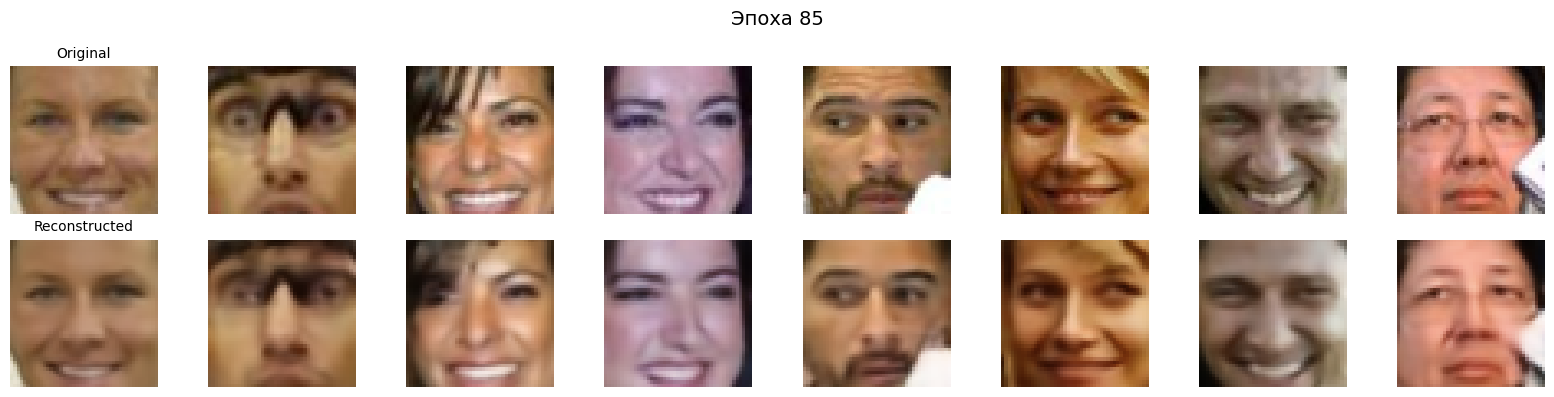

Epoch  86/250 | Time:   2.6s | Train Loss: 0.000785 | Val Loss: 0.001225  (Нет улучшений 22/50)
Epoch  87/250 | Time:   2.5s | Train Loss: 0.000794 | Val Loss: 0.001264  (Нет улучшений 23/50)
Epoch  88/250 | Time:   2.5s | Train Loss: 0.000781 | Val Loss: 0.001262  (Нет улучшений 24/50)
Epoch  89/250 | Time:   2.5s | Train Loss: 0.000786 | Val Loss: 0.001237  (Нет улучшений 25/50)
Epoch  90/250 | Time:   2.5s | Train Loss: 0.000768 | Val Loss: 0.001241  (Нет улучшений 26/50)


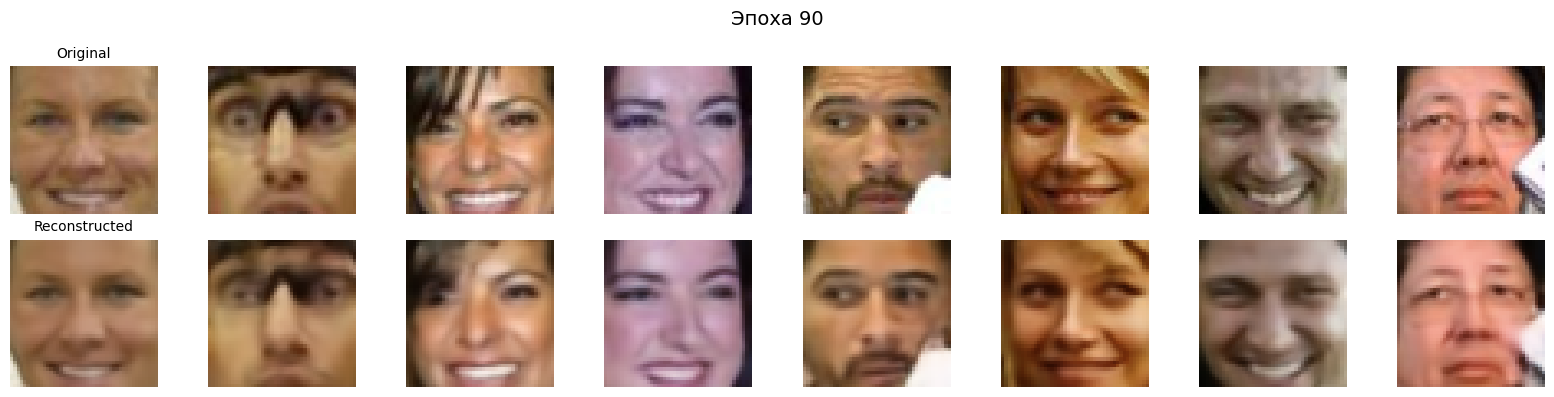

Epoch  91/250 | Time:   2.6s | Train Loss: 0.000797 | Val Loss: 0.001236  (Нет улучшений 27/50)
Epoch  92/250 | Time:   2.5s | Train Loss: 0.000770 | Val Loss: 0.001374  (Нет улучшений 28/50)
Epoch  93/250 | Time:   2.5s | Train Loss: 0.000804 | Val Loss: 0.001242  (Нет улучшений 29/50)
Epoch  94/250 | Time:   2.5s | Train Loss: 0.000751 | Val Loss: 0.001213  << Лучшая модель сохранена >>
Epoch  95/250 | Time:   2.6s | Train Loss: 0.000784 | Val Loss: 0.001279  (Нет улучшений 1/50)


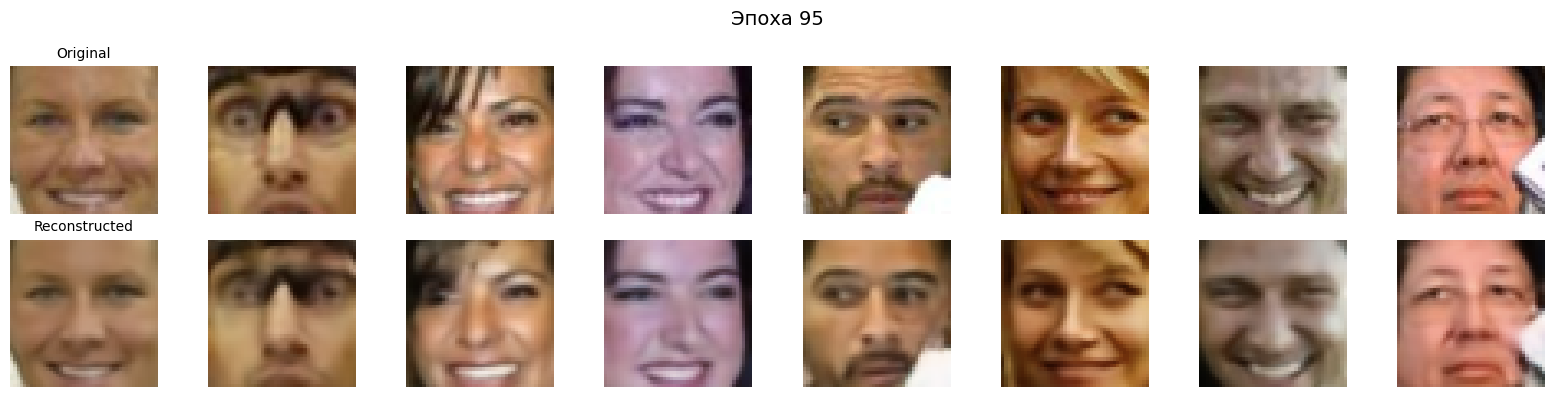

Epoch  96/250 | Time:   2.6s | Train Loss: 0.000763 | Val Loss: 0.001250  (Нет улучшений 2/50)
Epoch  97/250 | Time:   2.5s | Train Loss: 0.000764 | Val Loss: 0.001250  (Нет улучшений 3/50)
Epoch  98/250 | Time:   2.5s | Train Loss: 0.000763 | Val Loss: 0.001229  (Нет улучшений 4/50)
Epoch  99/250 | Time:   2.5s | Train Loss: 0.000762 | Val Loss: 0.001232  (Нет улучшений 5/50)
Epoch 100/250 | Time:   2.6s | Train Loss: 0.000754 | Val Loss: 0.001262  (Нет улучшений 6/50)


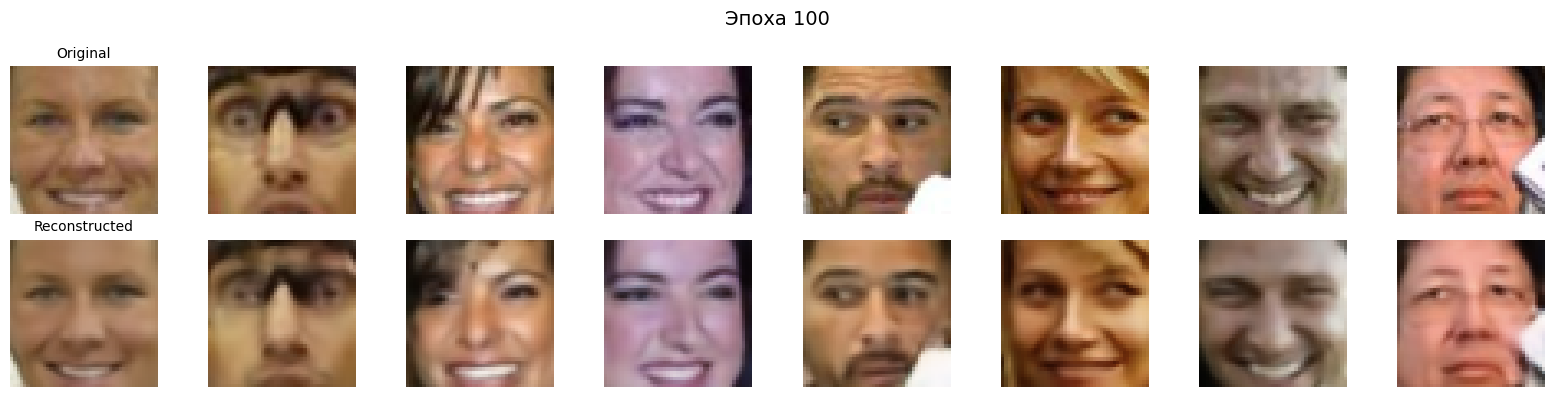

Epoch 101/250 | Time:   2.6s | Train Loss: 0.000765 | Val Loss: 0.001272  (Нет улучшений 7/50)
Epoch 102/250 | Time:   2.5s | Train Loss: 0.000748 | Val Loss: 0.001275  (Нет улучшений 8/50)
Epoch 103/250 | Time:   2.5s | Train Loss: 0.000775 | Val Loss: 0.001245  (Нет улучшений 9/50)
Epoch 104/250 | Time:   2.5s | Train Loss: 0.000739 | Val Loss: 0.001233  (Нет улучшений 10/50)
Epoch 105/250 | Time:   2.6s | Train Loss: 0.000747 | Val Loss: 0.001355  (Нет улучшений 11/50)


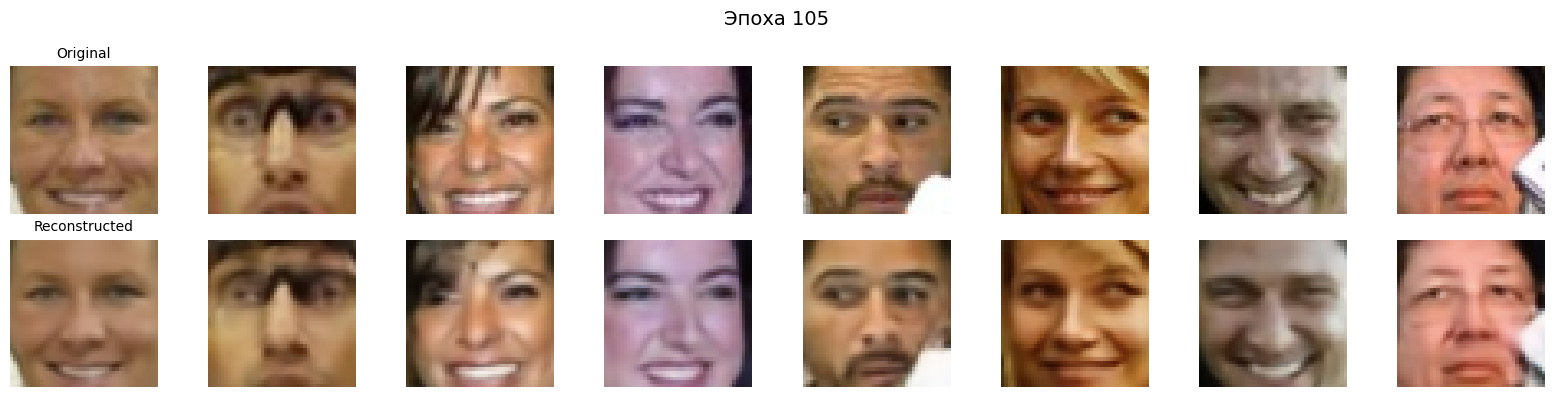

Epoch 106/250 | Time:   2.5s | Train Loss: 0.000736 | Val Loss: 0.001229  (Нет улучшений 12/50)
Epoch 107/250 | Time:   2.5s | Train Loss: 0.000751 | Val Loss: 0.001257  (Нет улучшений 13/50)
Epoch 108/250 | Time:   2.5s | Train Loss: 0.000754 | Val Loss: 0.001238  (Нет улучшений 14/50)
Epoch 109/250 | Time:   2.5s | Train Loss: 0.000739 | Val Loss: 0.001263  (Нет улучшений 15/50)
Epoch 110/250 | Time:   2.6s | Train Loss: 0.000737 | Val Loss: 0.001242  (Нет улучшений 16/50)


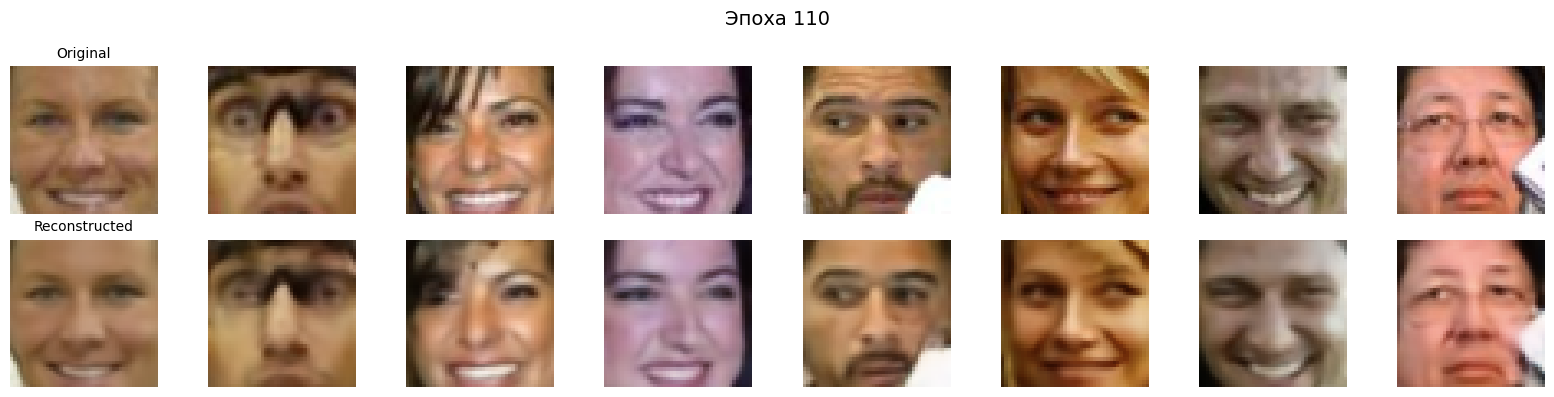

Epoch 111/250 | Time:   2.5s | Train Loss: 0.000725 | Val Loss: 0.001253  (Нет улучшений 17/50)
Epoch 112/250 | Time:   2.5s | Train Loss: 0.000751 | Val Loss: 0.001276  (Нет улучшений 18/50)
Epoch 113/250 | Time:   2.5s | Train Loss: 0.000736 | Val Loss: 0.001243  (Нет улучшений 19/50)
Epoch 114/250 | Time:   2.6s | Train Loss: 0.000734 | Val Loss: 0.001258  (Нет улучшений 20/50)
Epoch 115/250 | Time:   2.6s | Train Loss: 0.000734 | Val Loss: 0.001233  (Нет улучшений 21/50)


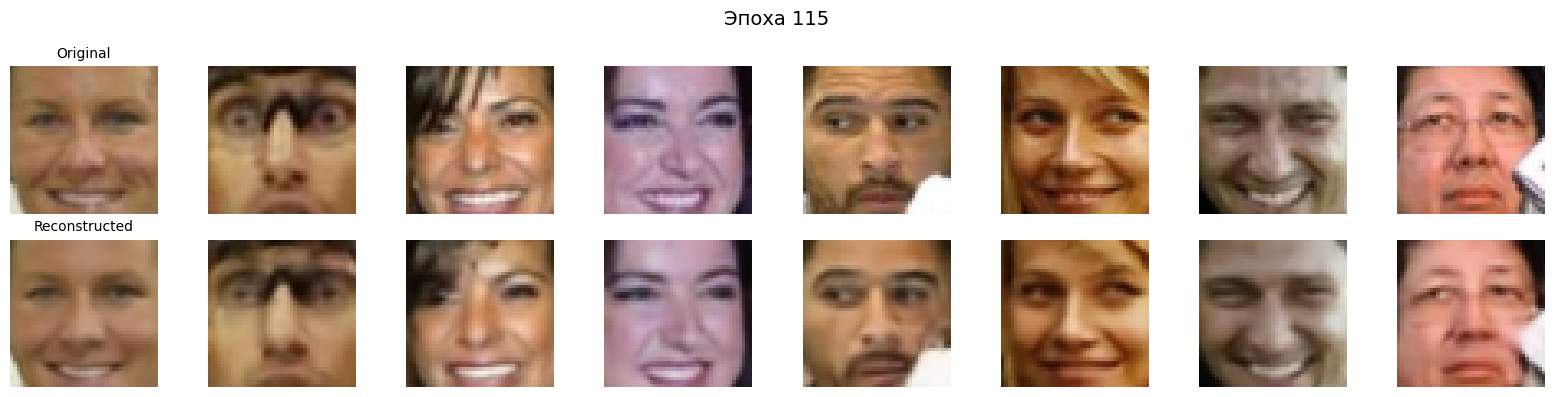

Epoch 116/250 | Time:   2.5s | Train Loss: 0.000723 | Val Loss: 0.001244  (Нет улучшений 22/50)
Epoch 117/250 | Time:   2.5s | Train Loss: 0.000741 | Val Loss: 0.001296  (Нет улучшений 23/50)
Epoch 118/250 | Time:   2.5s | Train Loss: 0.000721 | Val Loss: 0.001262  (Нет улучшений 24/50)
Epoch 119/250 | Time:   2.6s | Train Loss: 0.000738 | Val Loss: 0.001267  (Нет улучшений 25/50)
Epoch 120/250 | Time:   2.6s | Train Loss: 0.000717 | Val Loss: 0.001280  (Нет улучшений 26/50)


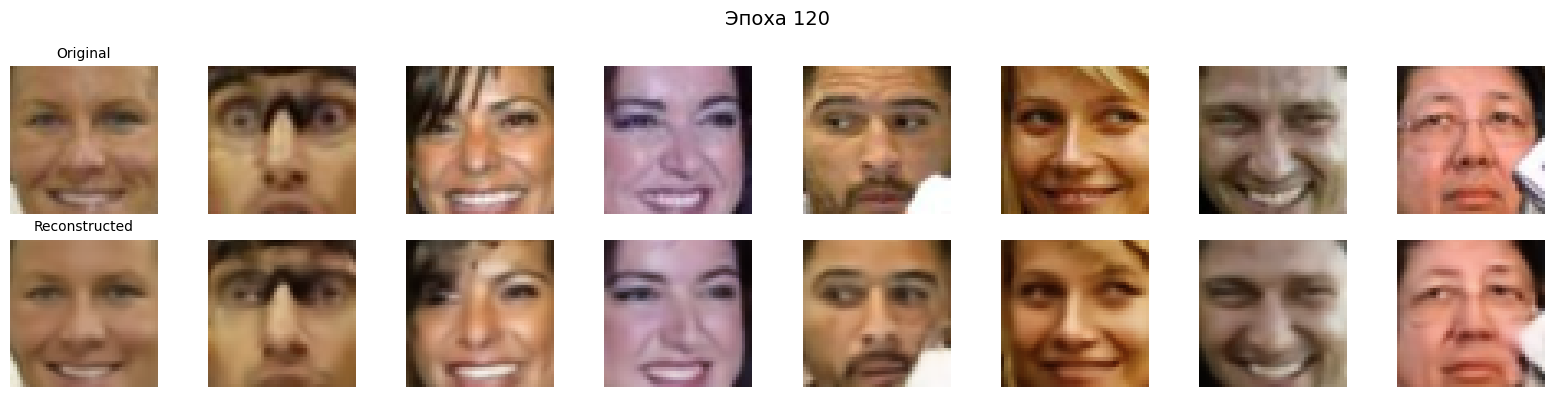

Epoch 121/250 | Time:   2.5s | Train Loss: 0.000732 | Val Loss: 0.001328  (Нет улучшений 27/50)
Epoch 122/250 | Time:   2.5s | Train Loss: 0.000719 | Val Loss: 0.001363  (Нет улучшений 28/50)
Epoch 123/250 | Time:   2.5s | Train Loss: 0.000715 | Val Loss: 0.001247  (Нет улучшений 29/50)
Epoch 124/250 | Time:   2.6s | Train Loss: 0.000724 | Val Loss: 0.001287  (Нет улучшений 30/50)
Epoch 125/250 | Time:   2.5s | Train Loss: 0.000717 | Val Loss: 0.001335  (Нет улучшений 31/50)


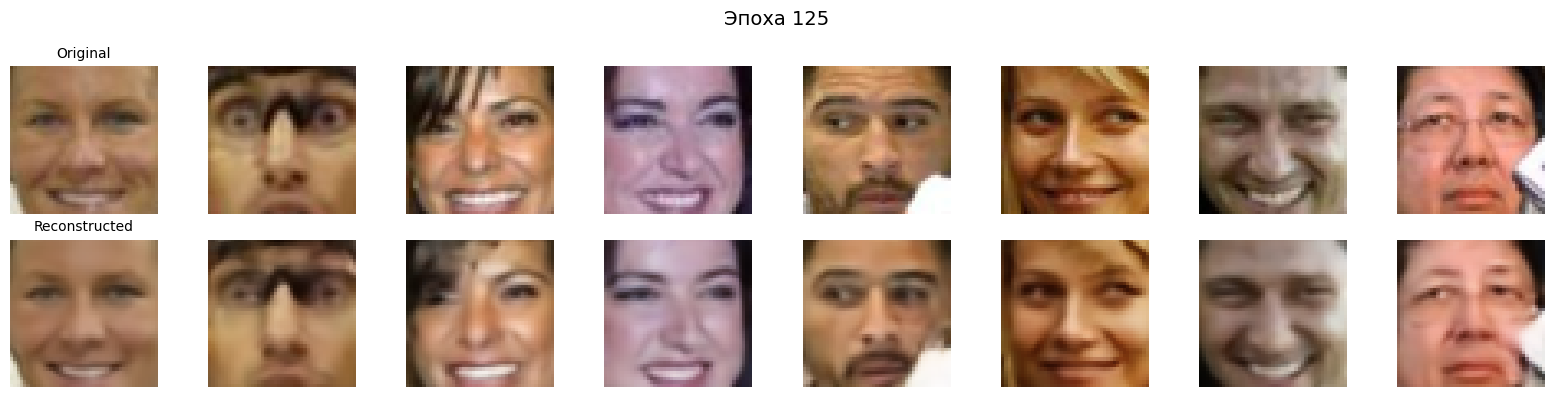

Epoch 126/250 | Time:   2.5s | Train Loss: 0.000711 | Val Loss: 0.001352  (Нет улучшений 32/50)
Epoch 127/250 | Time:   2.5s | Train Loss: 0.000713 | Val Loss: 0.001254  (Нет улучшений 33/50)
Epoch 128/250 | Time:   2.5s | Train Loss: 0.000744 | Val Loss: 0.001238  (Нет улучшений 34/50)
Epoch 129/250 | Time:   2.6s | Train Loss: 0.000702 | Val Loss: 0.001285  (Нет улучшений 35/50)
Epoch 130/250 | Time:   2.5s | Train Loss: 0.000699 | Val Loss: 0.001335  (Нет улучшений 36/50)


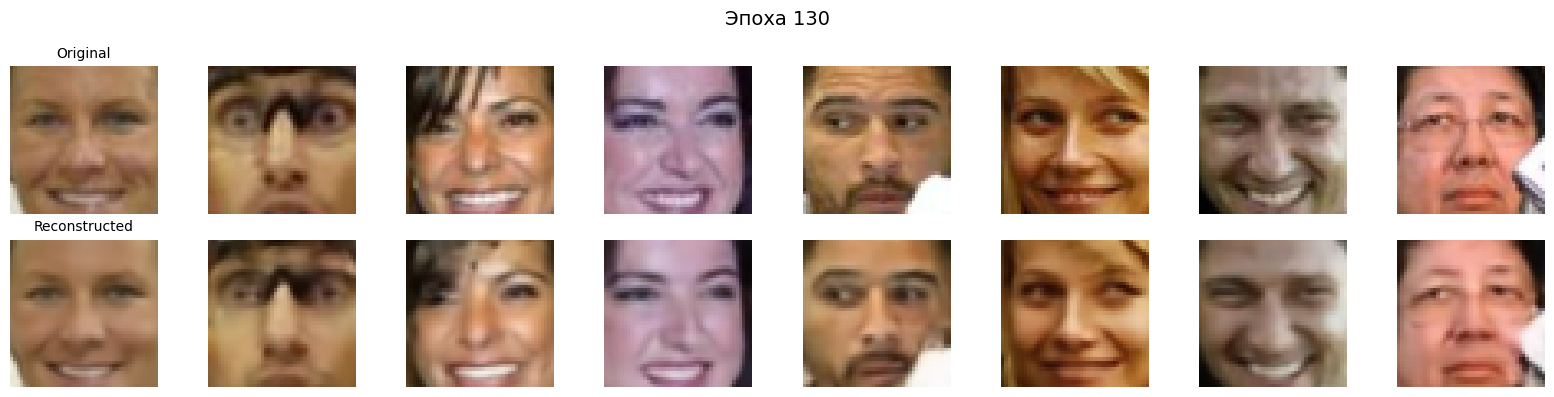

Epoch 131/250 | Time:   2.8s | Train Loss: 0.000721 | Val Loss: 0.001257  (Нет улучшений 37/50)
Epoch 132/250 | Time:   2.5s | Train Loss: 0.000708 | Val Loss: 0.001268  (Нет улучшений 38/50)
Epoch 133/250 | Time:   2.6s | Train Loss: 0.000714 | Val Loss: 0.001272  (Нет улучшений 39/50)
Epoch 134/250 | Time:   2.6s | Train Loss: 0.000695 | Val Loss: 0.001261  (Нет улучшений 40/50)
Epoch 135/250 | Time:   2.5s | Train Loss: 0.000699 | Val Loss: 0.001272  (Нет улучшений 41/50)


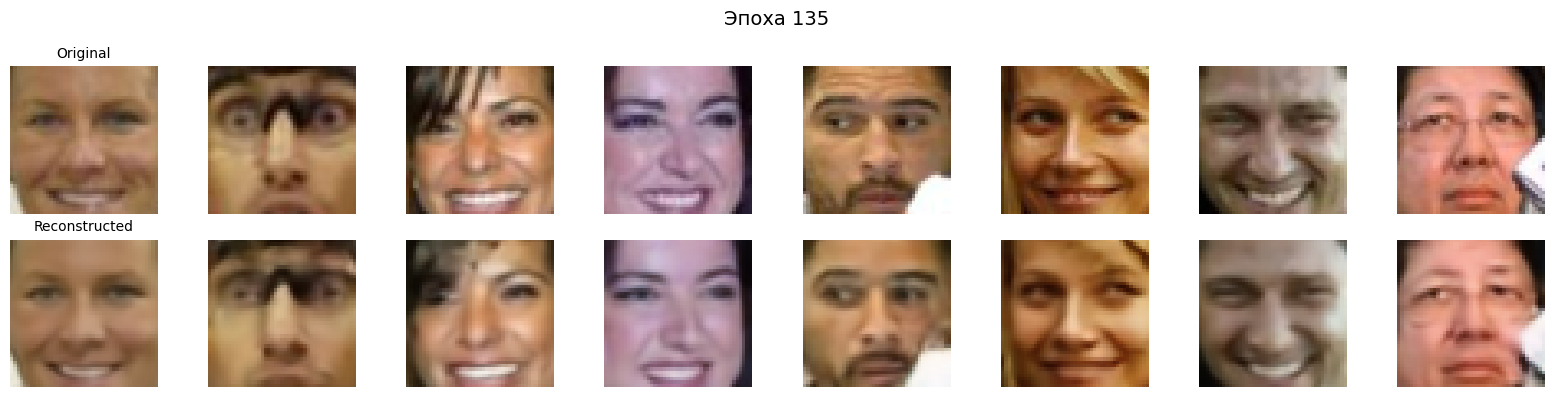

Epoch 136/250 | Time:   2.5s | Train Loss: 0.000703 | Val Loss: 0.001310  (Нет улучшений 42/50)
Epoch 137/250 | Time:   2.5s | Train Loss: 0.000708 | Val Loss: 0.001246  (Нет улучшений 43/50)
Epoch 138/250 | Time:   2.6s | Train Loss: 0.000686 | Val Loss: 0.001333  (Нет улучшений 44/50)
Epoch 139/250 | Time:   2.6s | Train Loss: 0.000732 | Val Loss: 0.001253  (Нет улучшений 45/50)
Epoch 140/250 | Time:   2.5s | Train Loss: 0.000679 | Val Loss: 0.001236  (Нет улучшений 46/50)


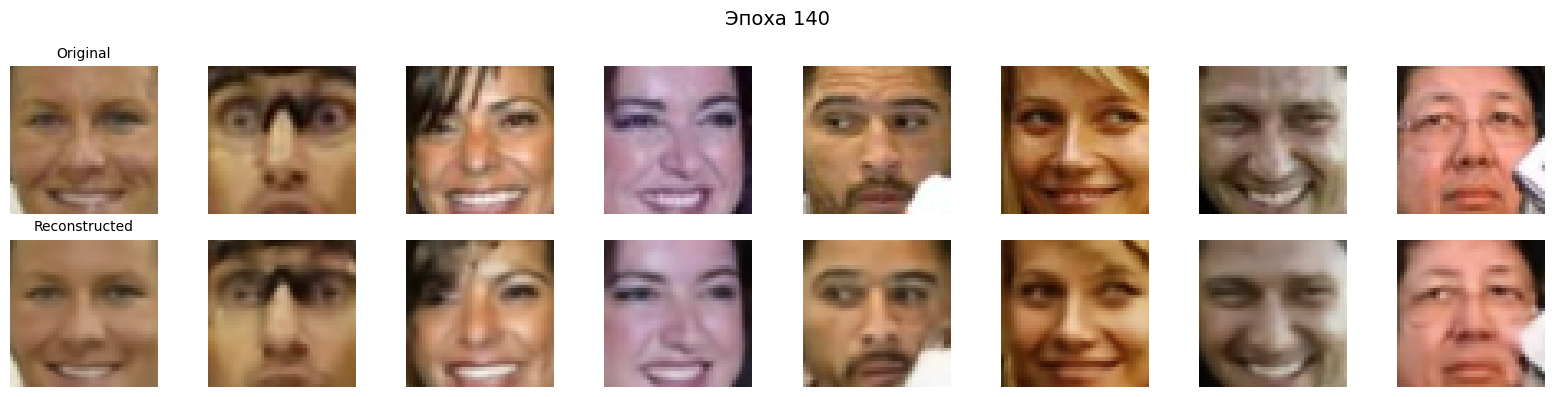

Epoch 141/250 | Time:   2.5s | Train Loss: 0.000719 | Val Loss: 0.001306  (Нет улучшений 47/50)
Epoch 142/250 | Time:   2.5s | Train Loss: 0.000695 | Val Loss: 0.001270  (Нет улучшений 48/50)
Epoch 143/250 | Time:   2.6s | Train Loss: 0.000684 | Val Loss: 0.001286  (Нет улучшений 49/50)
Epoch 144/250 | Time:   2.5s | Train Loss: 0.000696 | Val Loss: 0.001279  (Нет улучшений 50/50)

Early stopping на эпохе 144!


In [ ]:
model, history  = train_autoencoder(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=250,
    patience=50,
    device=device
)

In [ ]:
torch.save(model.state_dict(), '/content/drive/MyDrive/Colab Notebooks/DLS-1/auto_enk.pth')

Давайте посмотрим, как наш тренированный автоэнкодер кодирует и восстанавливает картинки:

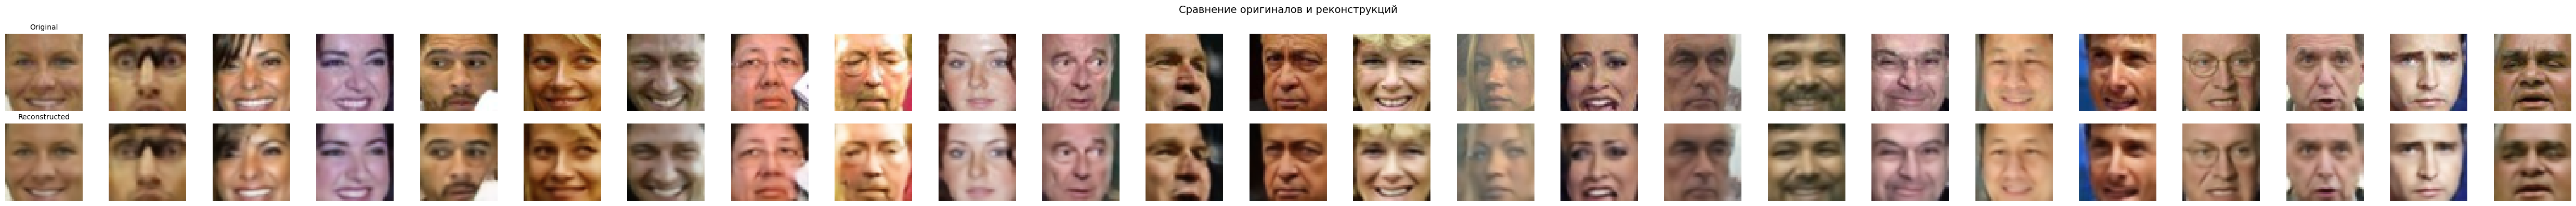

In [ ]:
# Убедимся, что модель находится в eval режиме и на нужном устройстве
model.eval()
device = next(model.parameters()).device

# Возьмём первые X изображений из val_tensor (например, 10)
X = 25
sample_val = val_tensor[:X].to(device)

with torch.no_grad():
    reconstructed, latent = model(sample_val)

# Переведём на CPU и изменим порядок осей для matplotlib: (N, C, H, W) -> (N, H, W, C)
origin_np = sample_val.cpu().permute(0, 2, 3, 1).numpy()
recon_np = reconstructed.cpu().permute(0, 2, 3, 1).numpy()

# Построим два ряда: верхний – оригиналы, нижний – реконструкции
fig, axes = plt.subplots(2, X, figsize=(2 * X, 4))
for i in range(X):
    axes[0, i].imshow(origin_np[i])
    axes[0, i].axis('off')
    axes[1, i].imshow(recon_np[i])
    axes[1, i].axis('off')
axes[0, 0].set_title('Original', fontsize=10)
axes[1, 0].set_title('Reconstructed', fontsize=10)
plt.suptitle('Сравнение оригиналов и реконструкций', fontsize=14)
plt.tight_layout()
plt.show()

Что вы можете сказать про результат?

Могу сказать, что результат хороший учитывая, что я использовал совсем базовые гиперпараметры для обучения и не очень большое количество эпох. Из плюсов: все основные элементы лиц хорошо различимы, лица похожи на исходные, какиех-то мутаций нет. Из минусов: какие то мелкие детали типа очков, морщин, носогубных складок или отеков конечно еле-еле различимы. Думаю, что если позаморачиваться с гиперпараметрами то результат станет лучше, но меня устраивает и так.

## 1.4. Sampling (2 балла)

Давайте теперь будем не просто брать картинку, прогонять ее через автоэнкодер и получать реконструкцию, а попробуем создать что-то НОВОЕ!

Давайте возьмем и подсунем декодеру какие-нибудь сгенерированные нами векторы (например, из нормального распределения) и посмотрим на результат реконструкции декодера:

__Подсказка:__ Если вместо лиц у вас выводится непонятно что, попробуйте посмотреть, как выглядят латентные векторы картинок из датасета. Так как в обучении нейронных сетей есть определенная доля рандома, векторы латентного слоя могут быть распределены НЕ как `np.random.randn(25, <latent_space_dim>)`. А чтобы у нас получались лица при запихивании вектора декодеру, вектор должен быть распределен так же, как латентные векторы реальных фоток. Так что в таком случае придется рандом немного подогнать.

Форма собранных латентных векторов: (3008, 256)
Среднее по измерениям: -0.0021 ± 0.0867
Стандартное отклонение по измерениям: 0.2349 ± 0.0991


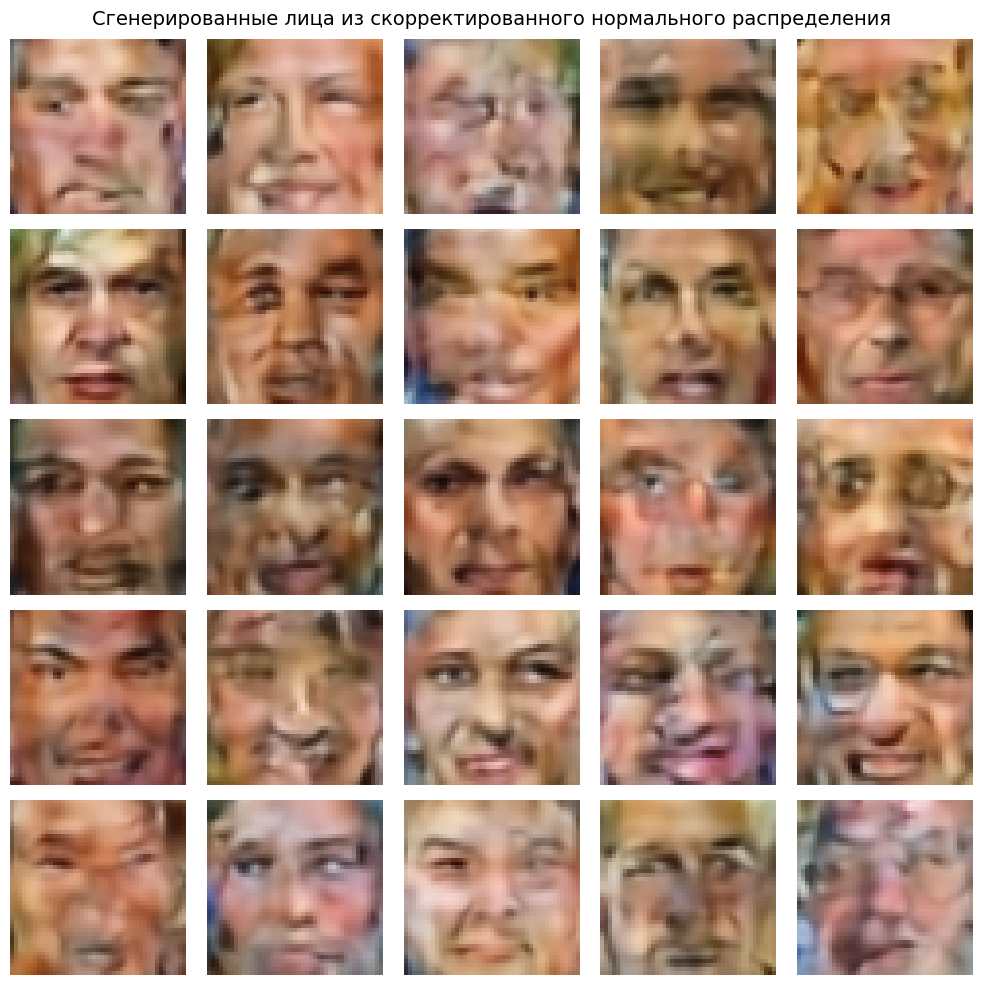

In [ ]:
# Переводим модель в eval-режим
model.eval()
device = next(model.parameters()).device

#Берем латентные векторы реальных изображений
latent_vectors = []
subset_size = min(3000, len(train_tensor))
with torch.no_grad():
    for i in range(0, subset_size, 64):  # батчами по 64
        batch = train_tensor[i:i+64].to(device)
        # Получаем только латентный код, реконструкция тут не нужна
        features = model.encoder(batch)
        flat = features.reshape(features.size(0), -1)
        z = model.fc_enc(flat)
        latent_vectors.append(z.cpu().numpy())

latent_vectors = np.concatenate(latent_vectors, axis=0)
print(f"Форма собранных латентных векторов: {latent_vectors.shape}")

# Вычисляем статистики
mean = latent_vectors.mean(axis=0)
std  = latent_vectors.std(axis=0)
print(f"Среднее по измерениям: {mean.mean():.4f} ± {mean.std():.4f}")
print(f"Стандартное отклонение по измерениям: {std.mean():.4f} ± {std.std():.4f}")

# Генерируем 25 новых векторов из скорректированного распределения
latent_dim = latent_vectors.shape[1]
z_rand = mean + std * np.random.randn(25, latent_dim)
z_tensor = torch.tensor(z_rand, dtype=torch.float32).to(device)

# Подаём векторы в декодер
with torch.no_grad():
    h = model.fc_dec(z_tensor)
    h = h.reshape(-1, 128, 6, 6)
    generated_images = model.decoder(h)

# Переводим в numpy и меняем оси для визуализации
gen_np = generated_images.cpu().permute(0, 2, 3, 1).numpy()

#Визуализация
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(np.clip(gen_np[i], 0, 1))  # на всякий случай клиппинг
    ax.axis('off')
plt.suptitle('Сгенерированные лица из скорректированного нормального распределения', fontsize=14)
plt.tight_layout()
plt.show()

Мутанты получились знатные, но на некоторых нормально различимы лица, так, что думаю опыт успешен)))

## 1.5 Time to make fun! (3 балла)

Давайте научимся пририсовывать людям улыбки =)

<img src="https://i.imgur.com/tOE9rDK.png" alt="linear" width="700" height="400">

План такой:

1. Нужно выделить "вектор улыбки": для этого нужно из выборки изображений найти несколько (~15) людей с улыбками и столько же без.

Найти людей с улыбками вам поможет файл с атрибутами, скачанный вместе с картинками. В нем указаны имена изображений и присутствубщие атрибуты (улыбки, очки и прочее интересное).

2. Вычислить латентный вектор для всех улыбающихся людей (прогнать их через encoder) и то же для всех грустненьких.

3. Вычислить, собственно, вектор улыбки -- посчитать разность между средним латентным вектором улыбающихся людей и средним латентным вектором грустных людей.

4. А теперь приделаем улыбку грустному человеку: добавим полученный в пункте 3 вектор к латентному вектору грустного человека и прогоним полученный вектор через decoder. Получим того же человека, но уже не грустненького!

In [ ]:
if train_attrs['Smiling'].dtype == object:
    train_attrs['Smiling'] = pd.to_numeric(train_attrs['Smiling'], errors='coerce')
    val_attrs['Smiling']   = pd.to_numeric(val_attrs['Smiling'], errors='coerce')

# Группируем по знаку: > 0 — улыбка, < 0 — без улыбки
smiling_idx = np.where(train_attrs['Smiling'].values > 0)[0]
non_smiling_idx = np.where(train_attrs['Smiling'].values < 0)[0]

print(f"Улыбающихся в train: {len(smiling_idx)}")
print(f"Неулыбающихся в train: {len(non_smiling_idx)}")

n_samples = 250
np.random.seed(42)
smiling_sample_idx = np.random.choice(smiling_idx, size=min(n_samples, len(smiling_idx)), replace=False)
non_smiling_sample_idx = np.random.choice(non_smiling_idx, size=min(n_samples, len(non_smiling_idx)), replace=False)

Улыбающихся в train: 4339
Неулыбающихся в train: 6175


/tmp/ipykernel_6577/2745526336.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_attrs['Smiling'] = pd.to_numeric(train_attrs['Smiling'], errors='coerce')
/tmp/ipykernel_6577/2745526336.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_attrs['Smiling']   = pd.to_numeric(val_attrs['Smiling'], errors='coerce')


In [ ]:
model.eval()
device = next(model.parameters()).device

def get_latent_vectors(img_tensor, indices, batch_size=32):
    vectors = []
    with torch.no_grad():
        for i in range(0, len(indices), batch_size):
            batch_idx = indices[i:i+batch_size]
            batch = img_tensor[batch_idx].to(device)
            _, z = model(batch)
            vectors.append(z.cpu().numpy())
    return np.concatenate(vectors, axis=0)

smiling_vecs = get_latent_vectors(train_tensor, smiling_sample_idx)
non_smiling_vecs = get_latent_vectors(train_tensor, non_smiling_sample_idx)
print(f"Латентные векторы: улыбающихся {smiling_vecs.shape}, неулыбающихся {non_smiling_vecs.shape}")

Латентные векторы: улыбающихся (250, 256), неулыбающихся (250, 256)


In [ ]:
mean_smiling = smiling_vecs.mean(axis=0)
mean_non_smiling = non_smiling_vecs.mean(axis=0)
smile_vector = mean_smiling - mean_non_smiling
print(f"Норма вектора улыбки: {np.linalg.norm(smile_vector):.4f}")

Норма вектора улыбки: 0.7593


Неулыбающихся в val: 1536


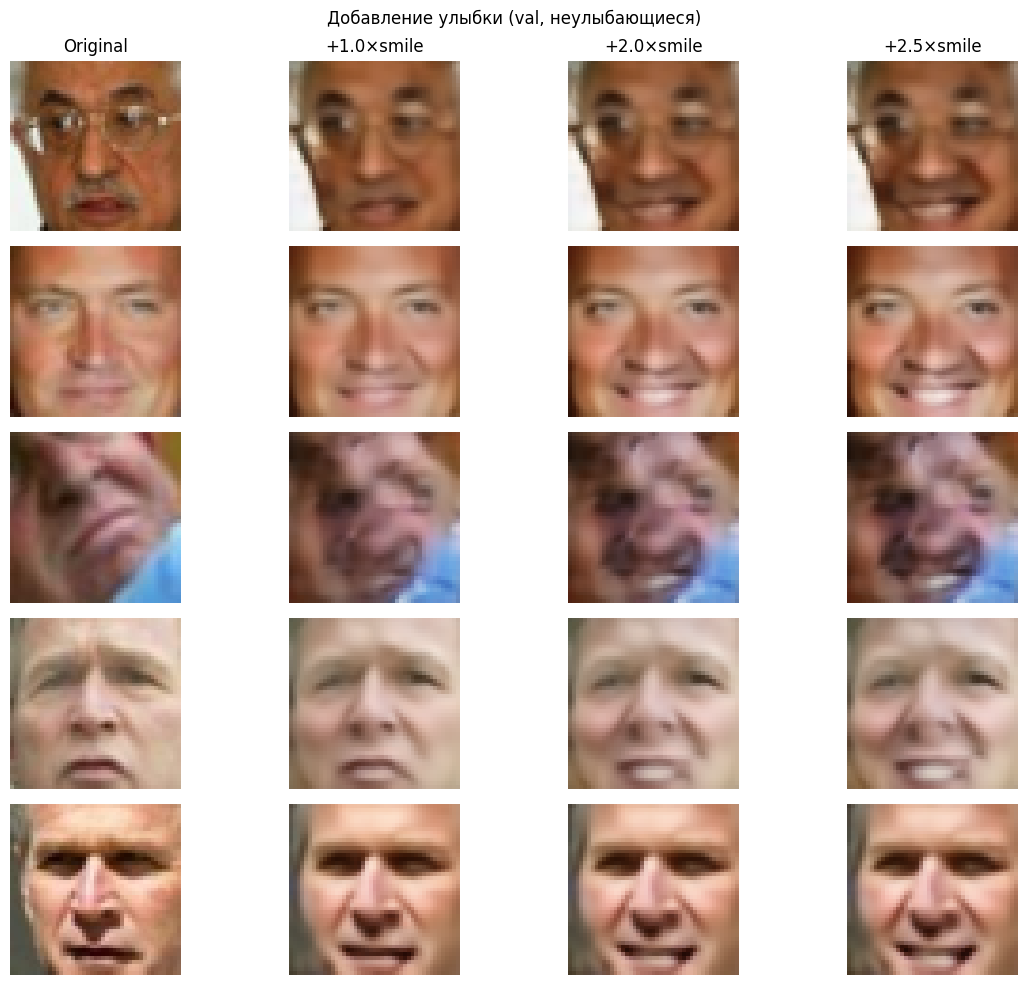

In [ ]:
val_non_smiling_idx = np.where(val_attrs['Smiling'].values < 0)[0]
print(f"Неулыбающихся в val: {len(val_non_smiling_idx)}")

# Выберем 5 случайных
demo_idx = np.random.choice(val_non_smiling_idx, size=min(5, len(val_non_smiling_idx)), replace=False)
original_images = val_tensor[demo_idx].to(device)

with torch.no_grad():
    _, latent_orig = model(original_images)
latent_orig_np = latent_orig.cpu().numpy()

# Коэффициенты усиления улыбки
coeffs = [1.0, 2.0, 2.5]

fig, axes = plt.subplots(len(demo_idx), 1 + len(coeffs), figsize=(3*(1+len(coeffs)), 2*len(demo_idx)))
for i in range(len(demo_idx)):
    # Оригинал
    img_orig = original_images[i].cpu().permute(1,2,0).numpy()
    axes[i,0].imshow(np.clip(img_orig, 0, 1))
    axes[i,0].axis('off')
    if i == 0:
        axes[i,0].set_title('Original')
    for j, coeff in enumerate(coeffs):
        new_latent = latent_orig_np[i] + coeff * smile_vector
        new_latent_tensor = torch.tensor(new_latent, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            h = model.fc_dec(new_latent_tensor)
            h = h.reshape(1, 128, 6, 6)
            gen_img = model.decoder(h)
        gen_np = gen_img.squeeze(0).cpu().permute(1,2,0).numpy()
        axes[i, j+1].imshow(np.clip(gen_np, 0, 1))
        axes[i, j+1].axis('off')
        if i == 0:
            axes[i, j+1].set_title(f'+{coeff}×smile')

plt.suptitle('Добавление улыбки (val, неулыбающиеся)')
plt.tight_layout()
plt.show()

Вуаля! Вы восхитительны!

Теперь вы можете пририсовывать людям не только улыбки, но и много чего другого -- закрывать/открывать глаза, пририсовывать очки... В общем, все, на что хватит фантазии и на что есть атрибуты в `attrs`:)

# Часть 2: Variational Autoencoder (10 баллов)

Займемся обучением вариационных автоэнкодеров — проапгрейженной версии AE. Обучать будем на датасете MNIST, содержащем написанные от руки цифры от 0 до 9

In [ ]:
from torchvision import transforms
from torch.utils.data import random_split

batch_size = 32

# Загружаем полный train_dataset
train_dataset_full = datasets.MNIST(root='./mnist_data/', train=True,
                                    transform=transforms.ToTensor(), download=True)

# Разбиваем на train и val, например 50 000 / 10 000
train_size = 50000
val_size = len(train_dataset_full) - train_size
train_dataset_mnist, val_dataset_mnist = random_split(train_dataset_full, [train_size, val_size])

# DataLoader-ы
batch_size = 32
train_loader_mnist = DataLoader(train_dataset_mnist, batch_size=batch_size, shuffle=True)
val_loader_mnist   = DataLoader(val_dataset_mnist,   batch_size=batch_size, shuffle=False)
test_loader_mnist  = DataLoader(datasets.MNIST(root='./mnist_data/', train=False,
                                         transform=transforms.ToTensor()),
                          batch_size=batch_size, shuffle=False)

## 2.1 Архитектура модели и обучение (2 балла)

Реализуем VAE. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Рекомендуем пользоваться более сложными моделями, чем та, что была на семинаре:) Экспериментируйте!

In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # Энкодер (вход 1 канал)
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),  # 28x28 -> 14x14
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # 14x14 -> 7x7
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),# 7x7 -> 7x7
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        self.flatten_dim = 128 * 7 * 7

        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

        # Декодер
        self.fc_dec = nn.Linear(latent_dim, self.flatten_dim)

        self.decoder_conv = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),          # 7x7 -> 14x14
            nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='nearest'),          # 14x14 -> 28x28
            nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 1, kernel_size=3, stride=1, padding=1), # 28x28, 1 канал
            nn.Sigmoid()
        )

    def encode(self, x):
        features = self.encoder_conv(x)
        flat = features.reshape(features.size(0), -1)
        mu = self.fc_mu(flat)
        logvar = self.fc_logvar(flat)
        return mu, logvar

    def gaussian_sampler(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + std * eps
        else:
            return mu

    def decode(self, z):
        h = self.fc_dec(z)
        h = h.view(-1, 128, 7, 7)
        reconstruction = self.decoder_conv(h)
        return reconstruction

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.gaussian_sampler(mu, logvar)
        reconstruction = self.decode(z)
        return mu, logvar, reconstruction

Определим лосс и его компоненты для VAE:

Надеюсь, вы уже прочитали материал в towardsdatascience (или еще где-то) про VAE и знаете, что лосс у VAE состоит из двух частей: KL и log-likelihood.

Общий лосс будет выглядеть так:

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x)||p(z)) + \log p_{\theta}(x|z)$$

Формула для KL-дивергенции:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$

В качестве log-likelihood возьмем привычную нам кросс-энтропию.

In [ ]:
import torch
import torch.nn.functional as F

def KL_divergence(mu, logsigma):


    kl = -0.5 * torch.sum(1 + logsigma - mu.pow(2) - logsigma.exp())
    return kl

def log_likelihood(x, reconstruction):

    return -F.binary_cross_entropy(reconstruction, x, reduction='sum')

def loss_vae(x, mu, logsigma, reconstruction):

    kl = KL_divergence(mu, logsigma)
    # Вместо того, чтобы отдельно вычислять log_likelihood и потом брать минус,
    # напрямую используе binary_cross_entropy (BCE), которая уже является отрицательным log-likelihood.
    bce = F.binary_cross_entropy(reconstruction, x, reduction='sum')
    loss = kl + bce
    return loss, kl, bce

И обучим модель:

In [ ]:
criterion = loss_vae

model_vae = VAE(latent_dim=64)

optimizer = torch.optim.Adam(model_vae.parameters(), lr=1e-3)

In [ ]:
# За основу взял прошлый код обучения, просто подогнал ее под особенности VAE

def train_vae(model, optimizer, train_loader, val_loader,
              num_epochs, patience, device, scheduler=None, vis_interval=5):

    model = model.to(device)
    history = {'train_loss': [], 'val_loss': [],
               'train_kl': [], 'val_kl': [],
               'train_bce': [], 'val_bce': []}
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_wts = None

    # зафиксируем батч для визуализации (из val)
    sample_batch, _ = next(iter(val_loader))
    sample_img = sample_batch[:8].to(device)

    for epoch in range(1, num_epochs + 1):
        # Обучение
        model.train()
        train_loss, train_kl, train_bce = 0.0, 0.0, 0.0
        for x, _ in train_loader:
            x = x.to(device)
            optimizer.zero_grad()
            mu, logvar, recon = model(x)
            loss, kl, bce = loss_vae(x, mu, logvar, recon)  # используею определённую ранее loss_vae
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_kl += kl.item()
            train_bce += bce.item()

        # усредним по размеру датасета
        num_train = len(train_loader.dataset)
        train_loss /= num_train
        train_kl   /= num_train
        train_bce  /= num_train

        # Валидация
        model.eval()
        val_loss, val_kl, val_bce = 0.0, 0.0, 0.0
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(device)
                mu, logvar, recon = model(x)
                loss, kl, bce = loss_vae(x, mu, logvar, recon)
                val_loss += loss.item()
                val_kl   += kl.item()
                val_bce  += bce.item()
        num_val = len(val_loader.dataset)
        val_loss /= num_val
        val_kl   /= num_val
        val_bce  /= num_val

        # сохраняем историю
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_kl'].append(train_kl)
        history['val_kl'].append(val_kl)
        history['train_bce'].append(train_bce)
        history['val_bce'].append(val_bce)

        print(f"Epoch {epoch:3d}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} KL: {train_kl:.4f} BCE: {train_bce:.4f} | "
              f"Val Loss: {val_loss:.4f} KL: {val_kl:.4f} BCE: {val_bce:.4f}", end="")

        # планировщик
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        # Ранняя остановка
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            best_model_wts = copy.deepcopy(model.state_dict())
            print("  << Лучшая модель сохранена >>")
        else:
            epochs_no_improve += 1
            print(f"  (нет улучшений {epochs_no_improve}/{patience})")
            if epochs_no_improve >= patience:
                print(f"\nEarly stopping на эпохе {epoch}!")
                break

        # визуализация
        if epoch % vis_interval == 0 or epoch == 1:
            model.eval()
            with torch.no_grad():
                _, _, recon_sample = model(sample_img)
            origin = sample_img.cpu().permute(0,2,3,1).numpy()
            recon  = recon_sample.cpu().permute(0,2,3,1).numpy()
            n = min(len(origin), 8)
            fig, axes = plt.subplots(2, n, figsize=(2*n, 4))
            for i in range(n):
                axes[0,i].imshow(origin[i].squeeze(), cmap='gray')
                axes[0,i].axis('off')
                axes[1,i].imshow(recon[i].squeeze(), cmap='gray')
                axes[1,i].axis('off')
            axes[0,0].set_title('Original')
            axes[1,0].set_title('Reconstructed')
            plt.suptitle(f'VAE Reconstruction – Epoch {epoch}')
            plt.tight_layout()
            plt.show()

    if best_model_wts is not None:
        model.load_state_dict(best_model_wts)
    return model, history

Epoch   1/30 | Train Loss: 96.6903 KL: 25.5150 BCE: 71.1753 | Val Loss: 87.7088 KL: 25.3591 BCE: 62.3497  << Лучшая модель сохранена >>


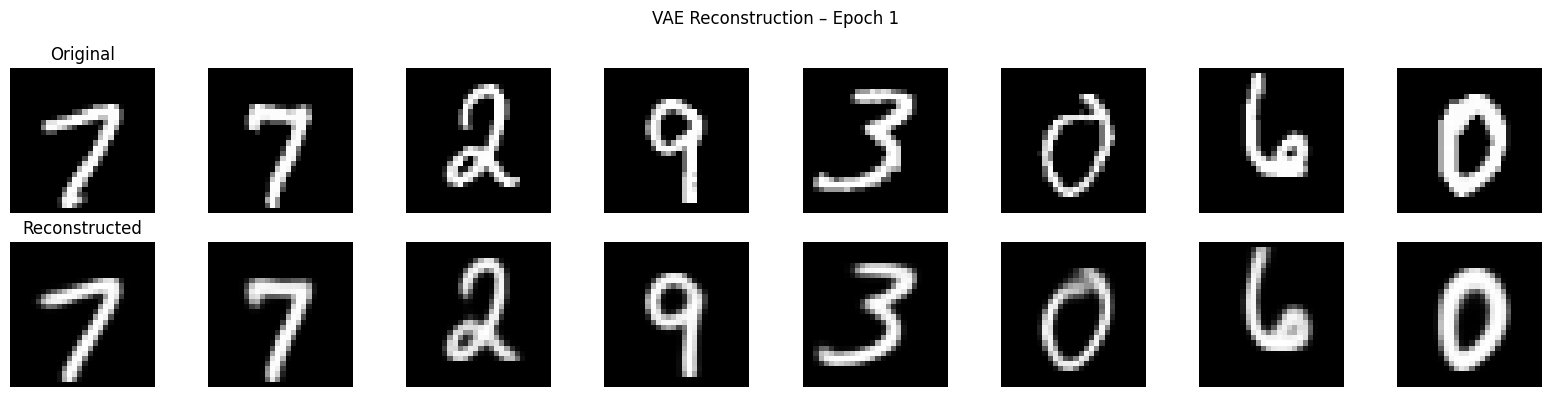

Epoch   2/30 | Train Loss: 96.5791 KL: 25.4913 BCE: 71.0877 | Val Loss: 87.5940 KL: 25.3120 BCE: 62.2820  << Лучшая модель сохранена >>
Epoch   3/30 | Train Loss: 96.5295 KL: 25.5112 BCE: 71.0183 | Val Loss: 87.6577 KL: 25.1492 BCE: 62.5084  (нет улучшений 1/10)
Epoch   4/30 | Train Loss: 96.4380 KL: 25.4719 BCE: 70.9661 | Val Loss: 88.0453 KL: 25.8359 BCE: 62.2095  (нет улучшений 2/10)
Epoch   5/30 | Train Loss: 96.3621 KL: 25.4500 BCE: 70.9121 | Val Loss: 87.3586 KL: 25.2496 BCE: 62.1090  << Лучшая модель сохранена >>


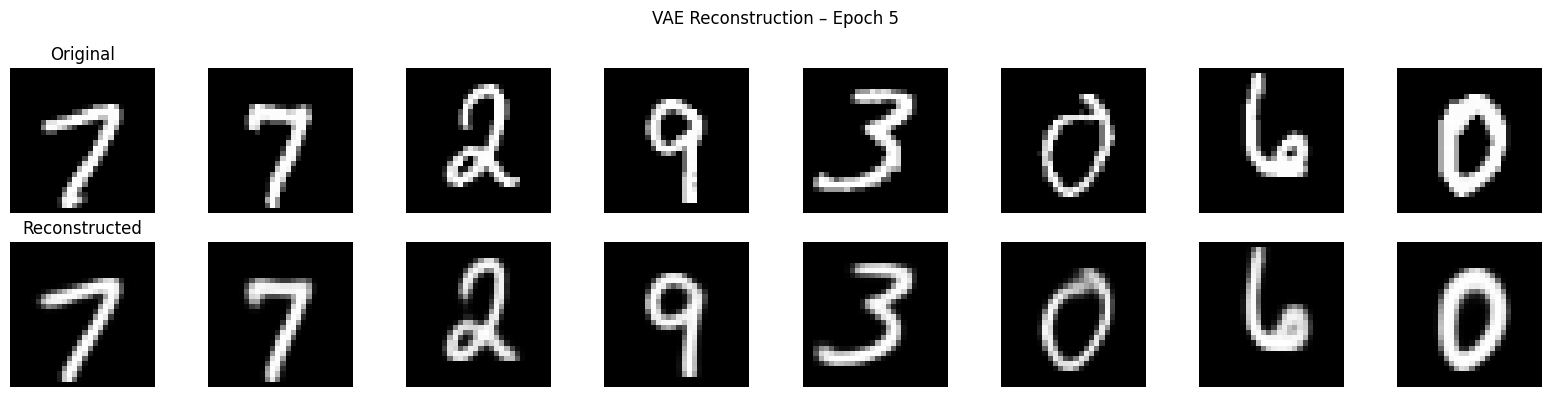

Epoch   6/30 | Train Loss: 96.2614 KL: 25.4140 BCE: 70.8474 | Val Loss: 87.1132 KL: 24.8675 BCE: 62.2457  << Лучшая модель сохранена >>
Epoch   7/30 | Train Loss: 96.1560 KL: 25.3733 BCE: 70.7827 | Val Loss: 87.5947 KL: 25.3363 BCE: 62.2585  (нет улучшений 1/10)
Epoch   8/30 | Train Loss: 96.0506 KL: 25.3262 BCE: 70.7245 | Val Loss: 87.4749 KL: 25.1775 BCE: 62.2973  (нет улучшений 2/10)
Epoch   9/30 | Train Loss: 96.0375 KL: 25.3250 BCE: 70.7125 | Val Loss: 87.3092 KL: 25.2488 BCE: 62.0604  (нет улучшений 3/10)
Epoch  10/30 | Train Loss: 95.9297 KL: 25.2734 BCE: 70.6563 | Val Loss: 87.4182 KL: 25.3156 BCE: 62.1026  (нет улучшений 4/10)


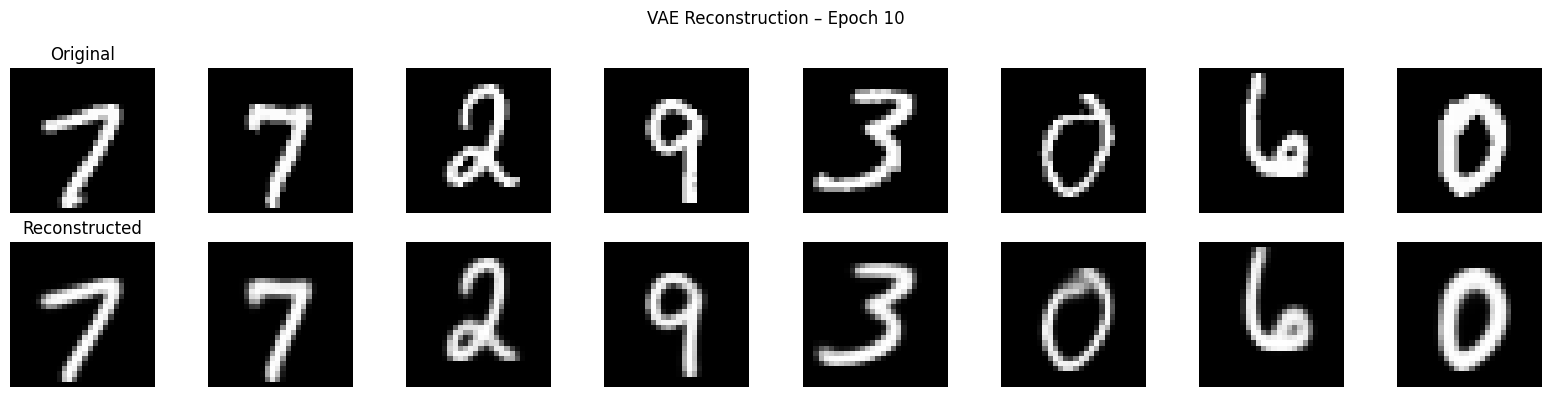

Epoch  11/30 | Train Loss: 95.9020 KL: 25.2911 BCE: 70.6109 | Val Loss: 86.4272 KL: 24.3022 BCE: 62.1250  << Лучшая модель сохранена >>
Epoch  12/30 | Train Loss: 95.8382 KL: 25.2670 BCE: 70.5712 | Val Loss: 87.3000 KL: 25.2615 BCE: 62.0385  (нет улучшений 1/10)
Epoch  13/30 | Train Loss: 95.7594 KL: 25.2609 BCE: 70.4986 | Val Loss: 87.2158 KL: 25.0590 BCE: 62.1568  (нет улучшений 2/10)
Epoch  14/30 | Train Loss: 95.7246 KL: 25.2252 BCE: 70.4994 | Val Loss: 87.1177 KL: 25.0930 BCE: 62.0247  (нет улучшений 3/10)
Epoch  15/30 | Train Loss: 95.6492 KL: 25.2102 BCE: 70.4391 | Val Loss: 87.3834 KL: 25.2807 BCE: 62.1026  (нет улучшений 4/10)


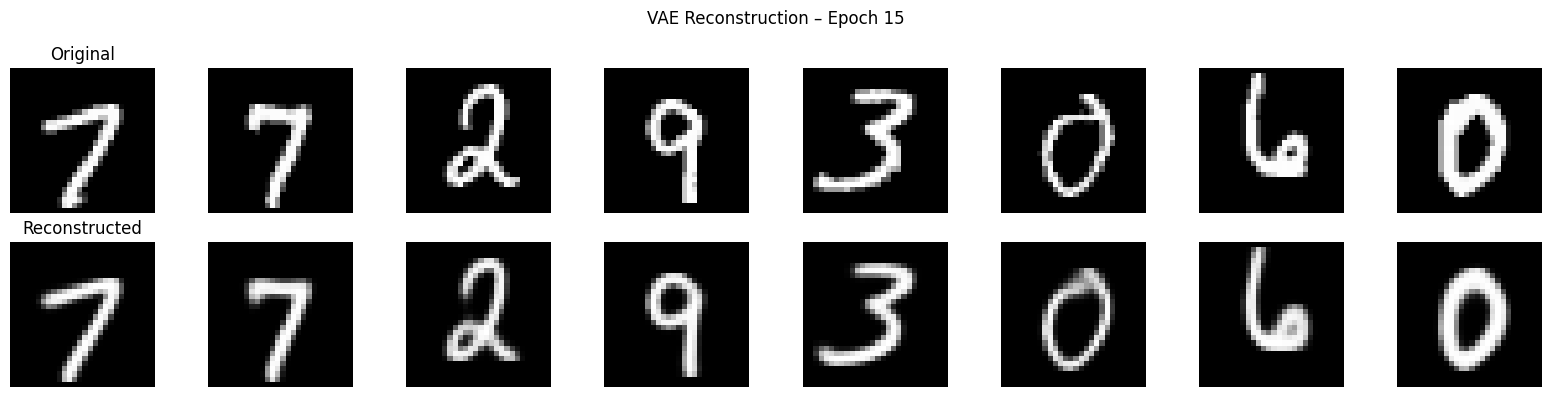

Epoch  16/30 | Train Loss: 95.6166 KL: 25.2076 BCE: 70.4090 | Val Loss: 87.0914 KL: 24.9071 BCE: 62.1842  (нет улучшений 5/10)
Epoch  17/30 | Train Loss: 95.5307 KL: 25.1632 BCE: 70.3675 | Val Loss: 86.9953 KL: 24.7863 BCE: 62.2090  (нет улучшений 6/10)
Epoch  18/30 | Train Loss: 95.4844 KL: 25.1388 BCE: 70.3456 | Val Loss: 87.2963 KL: 25.1457 BCE: 62.1506  (нет улучшений 7/10)
Epoch  19/30 | Train Loss: 95.4831 KL: 25.1649 BCE: 70.3181 | Val Loss: 87.6139 KL: 25.6850 BCE: 61.9289  (нет улучшений 8/10)
Epoch  20/30 | Train Loss: 95.3266 KL: 25.0986 BCE: 70.2280 | Val Loss: 86.6851 KL: 24.6684 BCE: 62.0167  (нет улучшений 9/10)


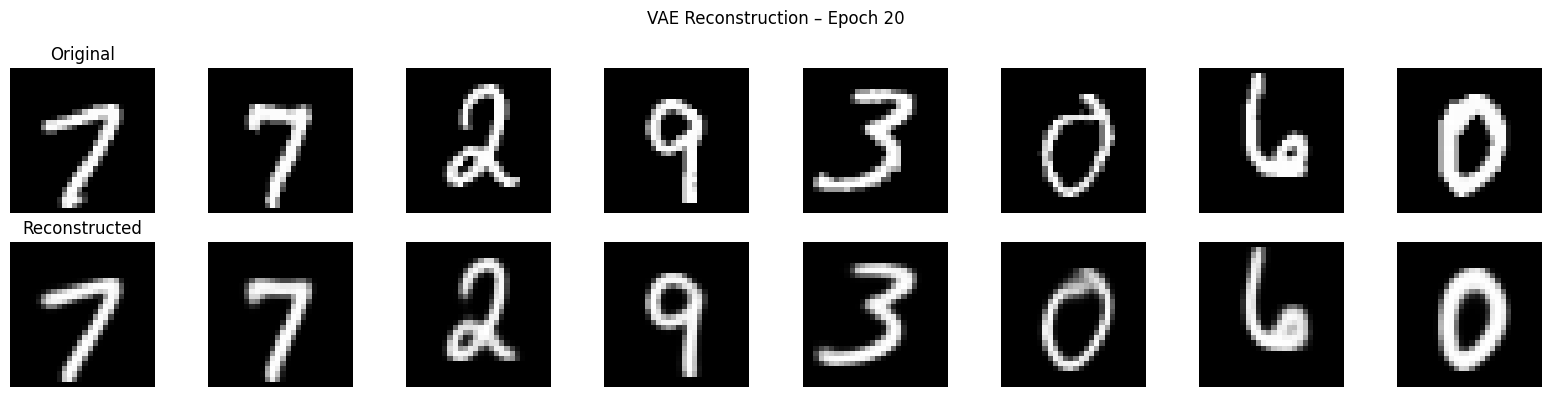

Epoch  21/30 | Train Loss: 95.3070 KL: 25.0873 BCE: 70.2196 | Val Loss: 87.5992 KL: 25.4778 BCE: 62.1214  (нет улучшений 10/10)

Early stopping на эпохе 21!


In [ ]:
trained_vae, history = train_vae(
    model=model_vae,
    optimizer=optimizer,
    train_loader=train_loader_mnist,   # MNIST train_loader
    val_loader=val_loader_mnist,      # MNIST test_loader
    num_epochs=30,
    patience=10,
    device=device
)

Давайте посмотрим, как наш тренированный VAE кодирует и восстанавливает картинки:

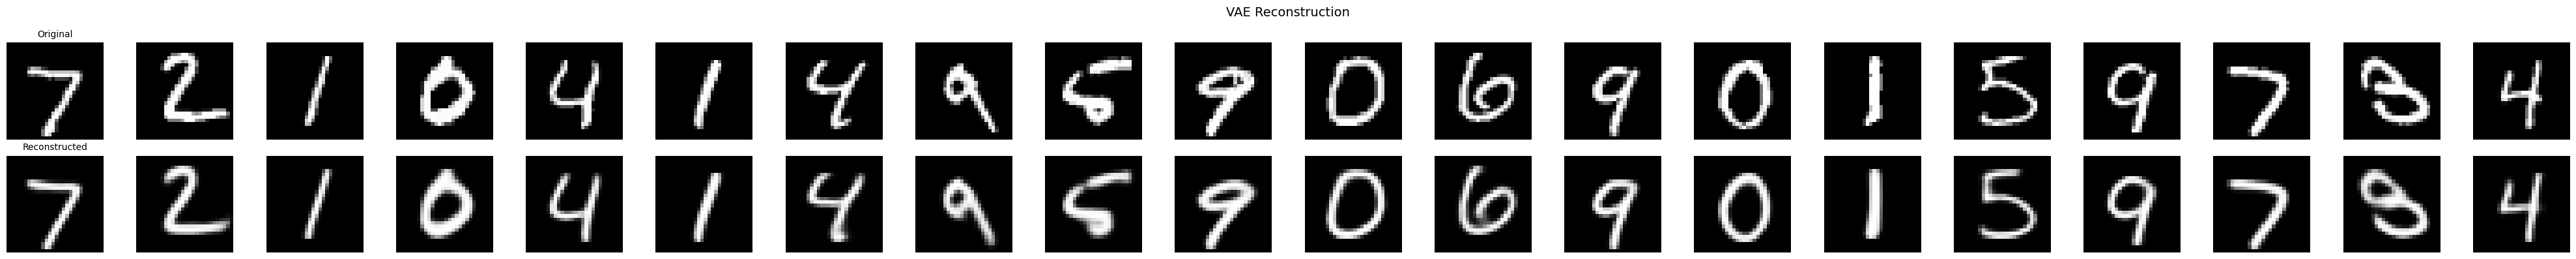

In [ ]:
# Переводим модель в eval-режим и определяем устройство
trained_vae.eval()
device = next(trained_vae.parameters()).device

# Берём X изображений из тестового (или валидационного) загрузчика
X = 20
sample_batch, _ = next(iter(test_loader_mnist))   # можно заменить на val_loader
sample_img = sample_batch[:X].to(device)

# Прогоняем через VAE (нам нужна только реконструкция)
with torch.no_grad():
    _, _, reconstruction = trained_vae(sample_img)

# Переносим на CPU и меняем оси для matplotlib: (N, C, H, W) -> (N, H, W, C)
origin_np = sample_img.cpu().permute(0, 2, 3, 1).numpy()
recon_np = reconstruction.cpu().permute(0, 2, 3, 1).numpy()

# MNIST одноканальный, поэтому убираем последнюю размерность (1) для imshow
origin_np = origin_np.squeeze(-1)  # (X, 28, 28)
recon_np = recon_np.squeeze(-1)

# Визуализация: два ряда – оригиналы и реконструкции
fig, axes = plt.subplots(2, X, figsize=(2 * X, 4))
for i in range(X):
    axes[0, i].imshow(origin_np[i], cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(recon_np[i], cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_title('Original', fontsize=10)
axes[1, 0].set_title('Reconstructed', fontsize=10)
plt.suptitle('VAE Reconstruction', fontsize=14)
plt.tight_layout()
plt.show()

Давайте попробуем проделать для VAE то же, что и с обычным автоэнкодером -- подсунуть decoder'у из VAE случайные векторы из нормального распределения и посмотреть, какие картинки получаются:

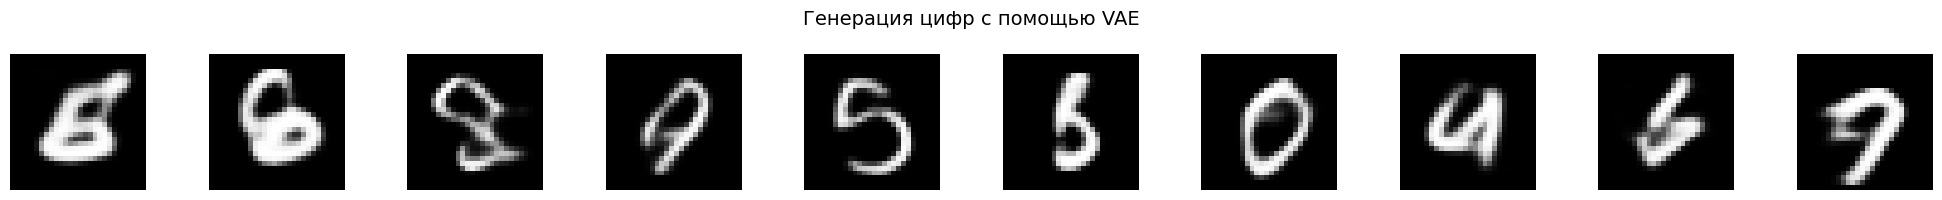

In [ ]:
trained_vae.eval()
device = next(trained_vae.parameters()).device

# Параметры генерации
n_samples = 10           # число генерируемых изображений
latent_dim = trained_vae.latent_dim

# Случайные латентные векторы из N(0, I)
z = np.random.normal(0, 1, (n_samples, latent_dim)).astype(np.float32)
z_tensor = torch.from_numpy(z).to(device)

# Прогоняем через декодер
with torch.no_grad():
    generated_images = trained_vae.decode(z_tensor)   # [n_samples, 1, 28, 28]

# Переносим на CPU и меняем оси для matplotlib
gen_np = generated_images.cpu().permute(0, 2, 3, 1).squeeze(-1).numpy()  # [n_samples, 28, 28]

# Визуализация в один ряд (или сеткой)
fig, axes = plt.subplots(1, n_samples, figsize=(2 * n_samples, 2))
for i, ax in enumerate(axes):
    ax.imshow(gen_np[i], cmap='gray')
    ax.axis('off')
plt.suptitle('Генерация цифр с помощью VAE', fontsize=14)
plt.tight_layout()
plt.show()

## 2.2. Latent Representation (2 балла)

Давайте посмотрим, как латентные векторы картинок лиц выглядят в пространстве.
Ваша задача -- изобразить латентные векторы картинок точками в двумерном просторанстве.

Это позволит оценить, насколько плотно распределены латентные векторы изображений цифр в пространстве.

Плюс давайте сделаем такую вещь: покрасим точки, которые соответствуют картинкам каждой цифры, в свой отдельный цвет

Подсказка: красить -- это просто =) У plt.scatter есть параметр c (color), см. в документации.


Итак, план:
1. Получить латентные представления картинок тестового датасета
2. С помощтю `TSNE` (есть в `sklearn`) сжать эти представления до размерности 2 (чтобы можно было их визуализировать точками в пространстве)
3. Визуализировать полученные двумерные представления с помощью `matplotlib.scatter`, покрасить разными цветами точки, соответствующие картинкам разных цифр.

Латентная размерность: 64, точек: 5000


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


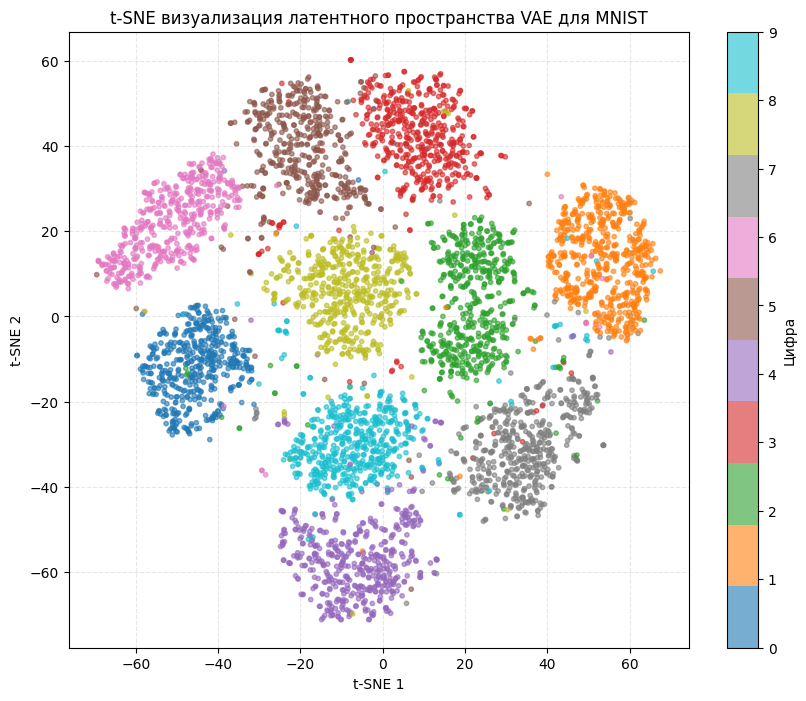

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Переводим модель в eval-режим
trained_vae.eval()
device = next(trained_vae.parameters()).device


max_samples = 5000
latent_vectors = []
labels = []

with torch.no_grad():
    for x, y in test_loader_mnist:
        x = x.to(device)
        mu, _ = trained_vae.encode(x)          # берём mu
        latent_vectors.append(mu.cpu().numpy())
        labels.append(y.numpy())

        # останавливаемся, когда набрали достаточно примеров
        if sum(len(l) for l in labels) >= max_samples:
            break

latent_vectors = np.concatenate(latent_vectors, axis=0)[:max_samples]
labels = np.concatenate(labels, axis=0)[:max_samples]

print(f"Латентная размерность: {latent_vectors.shape[1]}, точек: {len(latent_vectors)}")

# Применяем t‑SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
latent_2d = tsne.fit_transform(latent_vectors)

# Визуализация
plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1],
                      c=labels, cmap='tab10', alpha=0.6, s=10)

plt.colorbar(scatter, ticks=range(10), label='Цифра')
plt.title('t‑SNE визуализация латентного пространства VAE для MNIST')
plt.xlabel('t‑SNE 1')
plt.ylabel('t‑SNE 2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

Что вы думаете о виде латентного представления?

In [ ]:
Есть небольшое пересечение между схожими классами, но это нормально. В целом результат хороший, все классы четко отделены друг от друга.

__Congrats v2.0!__

## 2.3. Conditional VAE (6 баллов)


Мы уже научились обучать обычный AE на датасете картинок и получать новые картинки, используя генерацию шума и декодер.
Давайте теперь допустим, что мы обучили AE на датасете MNIST и теперь хотим генерировать новые картинки с числами с помощью декодера (как выше мы генерили рандомные лица).
И вот нам понадобилось сгенерировать цифру 8, и мы подставляем разные варианты шума, но восьмерка никак не генерится:(

Хотелось бы добавить к нашему AE функцию "выдай мне рандомное число из вот этого вот класса", где классов десять (цифры от 0 до 9 образуют десять классов).  Conditional AE — так называется вид автоэнкодера, который предоставляет такую возможность. Ну, название "conditional" уже говорит само за себя.

И в этой части задания мы научимся такие обучать.

### Архитектура

На картинке ниже представлена архитектура простого Conditional VAE.

По сути, единственное отличие от обычного -- это то, что мы вместе с картинкой в первом слое энкодера и декодера передаем еще информацию о классе картинки.

То есть, в первый (входной) слой энкодера подается конкатенация картинки и информации о классе (например, вектора из девяти нулей и одной единицы). В первый слой декодера подается конкатенация латентного вектора и информации о классе.


![alt text](https://sun9-63.userapi.com/impg/Mh1akf7mfpNoprrSWsPOouazSmTPMazYYF49Tw/djoHNw_9KVA.jpg?size=1175x642&quality=96&sign=e88baec5f9bb91c8443fba31dcf0a4df&type=album)

![alt text](https://sun9-73.userapi.com/impg/UDuloLNKhzTBYAKewgxke5-YPsAKyGOqA-qCRg/MnyCavJidxM.jpg?size=1229x651&quality=96&sign=f2d21bfacc1c5755b76868dc4cfef39c&type=album)



На всякий случай: это VAE, то есть, latent у него все еще состоит из mu и sigma

Таким образом, при генерации новой рандомной картинки мы должны будем передать декодеру сконкатенированные латентный вектор и класс картинки.

P.S. Также можно передавать класс картинки не только в первый слой, но и в каждый слой сети. То есть на каждом слое конкатенировать выход из предыдущего слоя и информацию о классе.

In [ ]:
class CVAE(nn.Module):
    def __init__(self, latent_dim=20, num_classes=10):

        super(CVAE, self).__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes

        # Энкодер
        # Вход: конкатенация по каналам изображения (1) и one-hot класса (num_classes)
        # Получаем 1 + num_classes = 11 каналов
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1 + num_classes, 32, kernel_size=3, stride=2, padding=1),  # 28x28 -> 14x14
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),               # 14x14 -> 7x7
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),              # 7x7 -> 7x7
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        self.flatten_dim = 128 * 7 * 7  # 6272

        # Два «хвоста» для mu и logvar
        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

        # Декодер

        self.fc_dec = nn.Linear(latent_dim + num_classes, self.flatten_dim)

        self.decoder_conv = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),          # 7x7 -> 14x14
            nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='nearest'),          # 14x14 -> 28x28
            nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 1, kernel_size=3, stride=1, padding=1), # 28x28, 1 канал
            nn.Sigmoid()
        )

    def _to_one_hot(self, class_num):

        B = class_num.size(0)
        # one-hot размер [B, num_classes]
        one_hot = torch.zeros(B, self.num_classes, device=class_num.device)
        one_hot.scatter_(1, class_num.unsqueeze(1), 1)
        # Расширяем до пространственных размеров изображения (28x28)
        one_hot = one_hot.unsqueeze(-1).unsqueeze(-1)  # [B, num_classes, 1, 1]
        one_hot = one_hot.expand(-1, -1, 28, 28)       # [B, num_classes, 28, 28]
        return one_hot

    def encode(self, x, class_num):
        "
        one_hot = self._to_one_hot(class_num)          # [B, num_classes, 28, 28]
        # Конкатенация по каналам
        x_cat = torch.cat([x, one_hot], dim=1)         # [B, 1+num_classes, 28, 28]
        features = self.encoder_conv(x_cat)            # [B, 128, 7, 7]
        flat = features.reshape(features.size(0), -1)  # [B, 6272]
        mu = self.fc_mu(flat)
        logvar = self.fc_logvar(flat)
        return mu, logvar, class_num

    def gaussian_sampler(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + std * eps
        else:
            return mu

    def decode(self, z, class_num):

        one_hot = self._to_one_hot(class_num)                      # [B, num_classes, 28, 28]
        # Для декодера конкатенируем z и one-hot, свёрнутый до 1D
        one_hot_1d = one_hot[:, :, 0, 0]                            # [B, num_classes]
        z_cat = torch.cat([z, one_hot_1d], dim=1)                  # [B, latent_dim + num_classes]
        h = self.fc_dec(z_cat)
        h = h.view(-1, 128, 7, 7)
        reconstruction = self.decoder_conv(h)
        return reconstruction

    def forward(self, x, class_num):

        mu, logvar, class_num = self.encode(x, class_num)
        z = self.gaussian_sampler(mu, logvar)
        reconstruction = self.decode(z, class_num)
        return mu, logvar, reconstruction, class_num

In [ ]:
def train_cvae(model, optimizer, train_loader, val_loader,
               num_epochs, patience, device, scheduler=None, vis_interval=5):

    model = model.to(device)
    history = {'train_loss': [], 'val_loss': [],
               'train_kl': [], 'val_kl': [],
               'train_bce': [], 'val_bce': []}
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_wts = None

    # фиксируем батч для визуализации (с метками)
    sample_batch, sample_labels = next(iter(val_loader))
    sample_img = sample_batch[:8].to(device)
    sample_labels = sample_labels[:8].to(device)

    for epoch in range(1, num_epochs + 1):
        # Обучение
        model.train()
        train_loss, train_kl, train_bce = 0.0, 0.0, 0.0
        for x, class_idx in train_loader:
            x = x.to(device)
            class_idx = class_idx.to(device)
            optimizer.zero_grad()
            mu, logvar, recon, _ = model(x, class_idx)
            loss, kl, bce = loss_vae(x, mu, logvar, recon)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_kl += kl.item()
            train_bce += bce.item()

        num_train = len(train_loader.dataset)
        train_loss /= num_train
        train_kl   /= num_train
        train_bce  /= num_train

        # Валидация
        model.eval()
        val_loss, val_kl, val_bce = 0.0, 0.0, 0.0
        with torch.no_grad():
            for x, class_idx in val_loader:
                x = x.to(device)
                class_idx = class_idx.to(device)
                mu, logvar, recon, _ = model(x, class_idx)
                loss, kl, bce = loss_vae(x, mu, logvar, recon)
                val_loss += loss.item()
                val_kl += kl.item()
                val_bce += bce.item()
        num_val = len(val_loader.dataset)
        val_loss /= num_val
        val_kl   /= num_val
        val_bce  /= num_val

        # сохраняем историю
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_kl'].append(train_kl)
        history['val_kl'].append(val_kl)
        history['train_bce'].append(train_bce)
        history['val_bce'].append(val_bce)

        print(f"Epoch {epoch:3d}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} KL: {train_kl:.4f} BCE: {train_bce:.4f} | "
              f"Val Loss: {val_loss:.4f} KL: {val_kl:.4f} BCE: {val_bce:.4f}", end="")

        # планировщик
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        # ранняя остановка
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            best_model_wts = copy.deepcopy(model.state_dict())
            print("  << Лучшая модель сохранена >>")
        else:
            epochs_no_improve += 1
            print(f"  (нет улучшений {epochs_no_improve}/{patience})")
            if epochs_no_improve >= patience:
                print(f"\nEarly stopping на эпохе {epoch}!")
                break

        # визуализация реконструкций с учётом класса
        if epoch % vis_interval == 0 or epoch == 1:
            model.eval()
            with torch.no_grad():
                _, _, recon_sample, _ = model(sample_img, sample_labels)
            origin = sample_img.cpu().permute(0,2,3,1).squeeze(-1).numpy()
            recon  = recon_sample.cpu().permute(0,2,3,1).squeeze(-1).numpy()
            n = min(len(origin), 8)
            fig, axes = plt.subplots(2, n, figsize=(2*n, 4))
            for i in range(n):
                axes[0,i].imshow(origin[i], cmap='gray')
                axes[0,i].set_title(f'Label: {sample_labels[i].item()}', fontsize=8)
                axes[0,i].axis('off')
                axes[1,i].imshow(recon[i], cmap='gray')
                axes[1,i].axis('off')
            axes[0,0].set_title('Original')
            axes[1,0].set_title('Reconstructed')
            plt.suptitle(f'CVAE Reconstruction – Epoch {epoch}')
            plt.tight_layout()
            plt.show()

    if best_model_wts is not None:
        model.load_state_dict(best_model_wts)
    return model, history

Epoch   1/30 | Train Loss: 120.4237 KL: 23.3272 BCE: 97.0965 | Val Loss: 93.3282 KL: 23.0672 BCE: 70.2610  << Лучшая модель сохранена >>


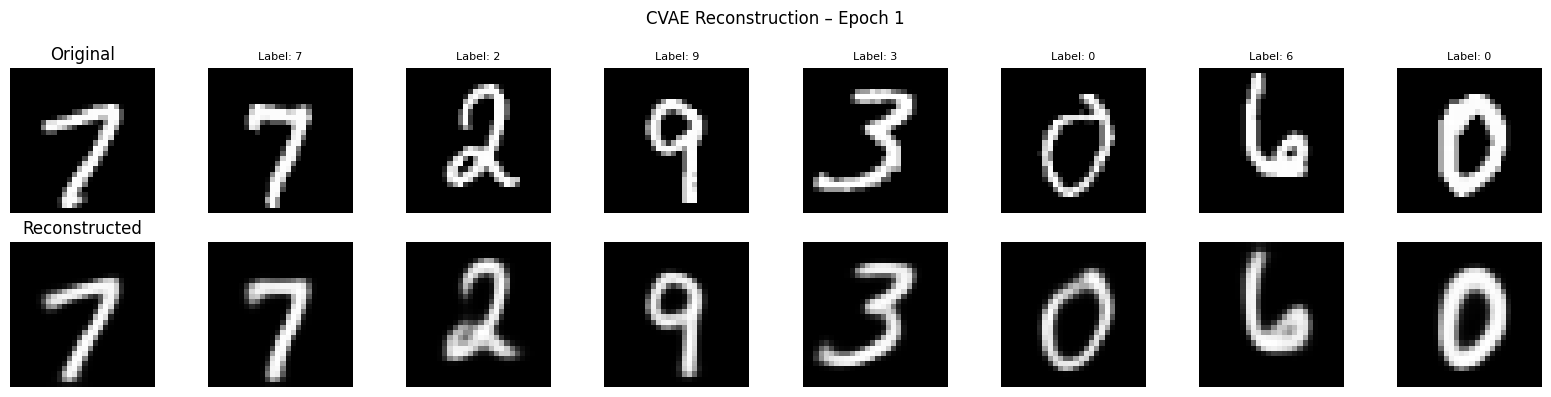

Epoch   2/30 | Train Loss: 103.4800 KL: 23.3173 BCE: 80.1627 | Val Loss: 91.1387 KL: 22.6217 BCE: 68.5170  << Лучшая модель сохранена >>
Epoch   3/30 | Train Loss: 101.0141 KL: 22.9268 BCE: 78.0873 | Val Loss: 90.5618 KL: 23.0475 BCE: 67.5143  << Лучшая модель сохранена >>
Epoch   4/30 | Train Loss: 99.4988 KL: 22.7041 BCE: 76.7947 | Val Loss: 88.6294 KL: 22.3075 BCE: 66.3218  << Лучшая модель сохранена >>
Epoch   5/30 | Train Loss: 98.4318 KL: 22.5252 BCE: 75.9066 | Val Loss: 88.5492 KL: 23.0468 BCE: 65.5025  << Лучшая модель сохранена >>


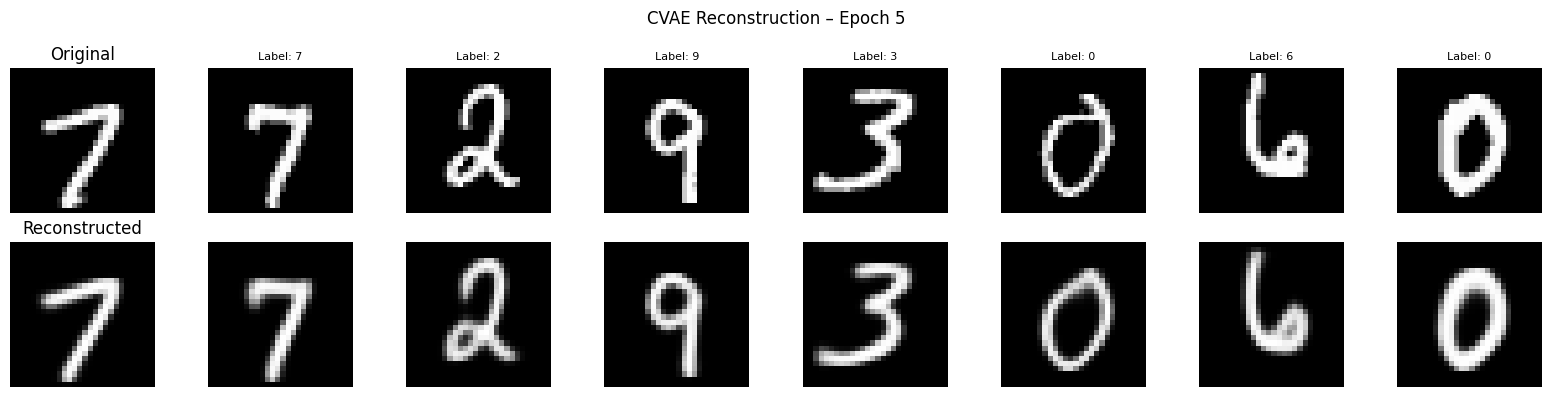

Epoch   6/30 | Train Loss: 97.5476 KL: 22.3716 BCE: 75.1760 | Val Loss: 86.8713 KL: 21.9593 BCE: 64.9120  << Лучшая модель сохранена >>
Epoch   7/30 | Train Loss: 96.8754 KL: 22.1936 BCE: 74.6818 | Val Loss: 86.7529 KL: 21.9425 BCE: 64.8104  << Лучшая модель сохранена >>
Epoch   8/30 | Train Loss: 96.1935 KL: 22.0405 BCE: 74.1531 | Val Loss: 85.9148 KL: 21.4286 BCE: 64.4863  << Лучшая модель сохранена >>
Epoch   9/30 | Train Loss: 95.7005 KL: 21.9712 BCE: 73.7293 | Val Loss: 85.9868 KL: 21.5401 BCE: 64.4466  (нет улучшений 1/5)
Epoch  10/30 | Train Loss: 95.3687 KL: 21.8474 BCE: 73.5214 | Val Loss: 86.3089 KL: 21.8019 BCE: 64.5070  (нет улучшений 2/5)


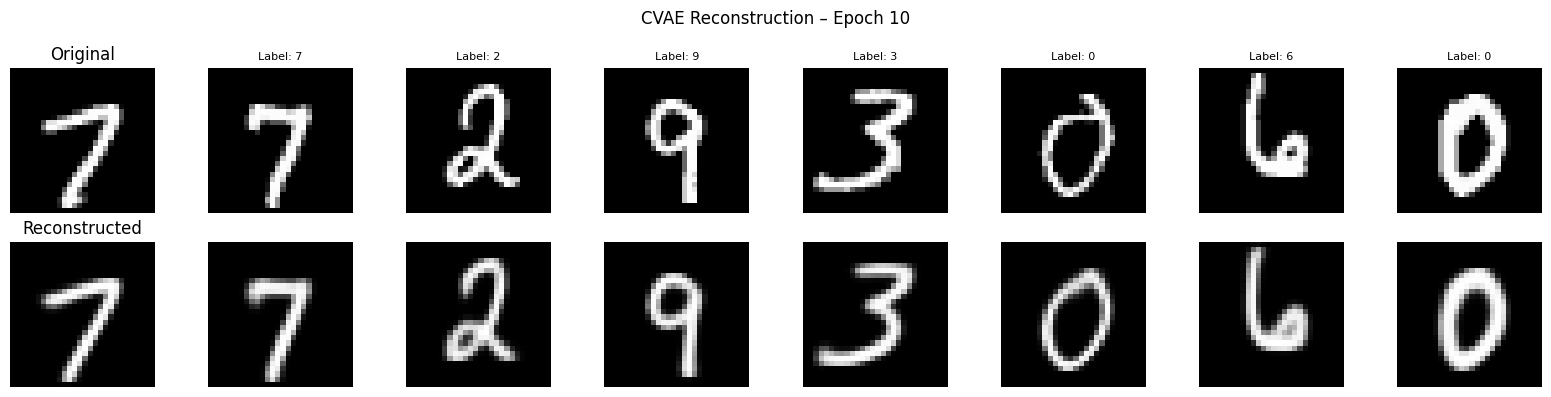

Epoch  11/30 | Train Loss: 94.8200 KL: 21.7036 BCE: 73.1163 | Val Loss: 86.0228 KL: 21.6521 BCE: 64.3707  (нет улучшений 3/5)
Epoch  12/30 | Train Loss: 94.5031 KL: 21.6305 BCE: 72.8725 | Val Loss: 85.2528 KL: 21.4947 BCE: 63.7581  << Лучшая модель сохранена >>
Epoch  13/30 | Train Loss: 94.2055 KL: 21.5636 BCE: 72.6419 | Val Loss: 85.4561 KL: 21.7758 BCE: 63.6803  (нет улучшений 1/5)
Epoch  14/30 | Train Loss: 93.9100 KL: 21.4781 BCE: 72.4319 | Val Loss: 84.9377 KL: 20.5139 BCE: 64.4238  << Лучшая модель сохранена >>
Epoch  15/30 | Train Loss: 93.6193 KL: 21.3934 BCE: 72.2259 | Val Loss: 85.4842 KL: 21.9607 BCE: 63.5235  (нет улучшений 1/5)


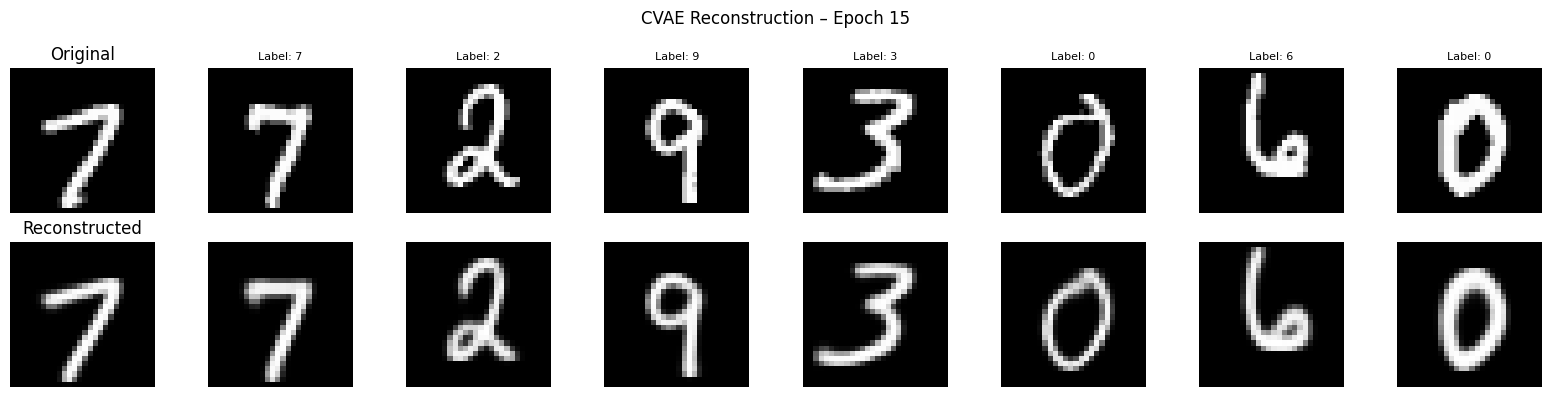

Epoch  16/30 | Train Loss: 93.3462 KL: 21.3181 BCE: 72.0282 | Val Loss: 85.3748 KL: 21.7557 BCE: 63.6191  (нет улучшений 2/5)
Epoch  17/30 | Train Loss: 93.0894 KL: 21.2677 BCE: 71.8217 | Val Loss: 84.8460 KL: 21.0448 BCE: 63.8012  << Лучшая модель сохранена >>
Epoch  18/30 | Train Loss: 92.8990 KL: 21.2283 BCE: 71.6707 | Val Loss: 85.0125 KL: 21.7941 BCE: 63.2184  (нет улучшений 1/5)
Epoch  19/30 | Train Loss: 92.7054 KL: 21.1722 BCE: 71.5332 | Val Loss: 84.0027 KL: 20.3029 BCE: 63.6998  << Лучшая модель сохранена >>
Epoch  20/30 | Train Loss: 92.4801 KL: 21.1205 BCE: 71.3596 | Val Loss: 84.2151 KL: 20.6695 BCE: 63.5456  (нет улучшений 1/5)


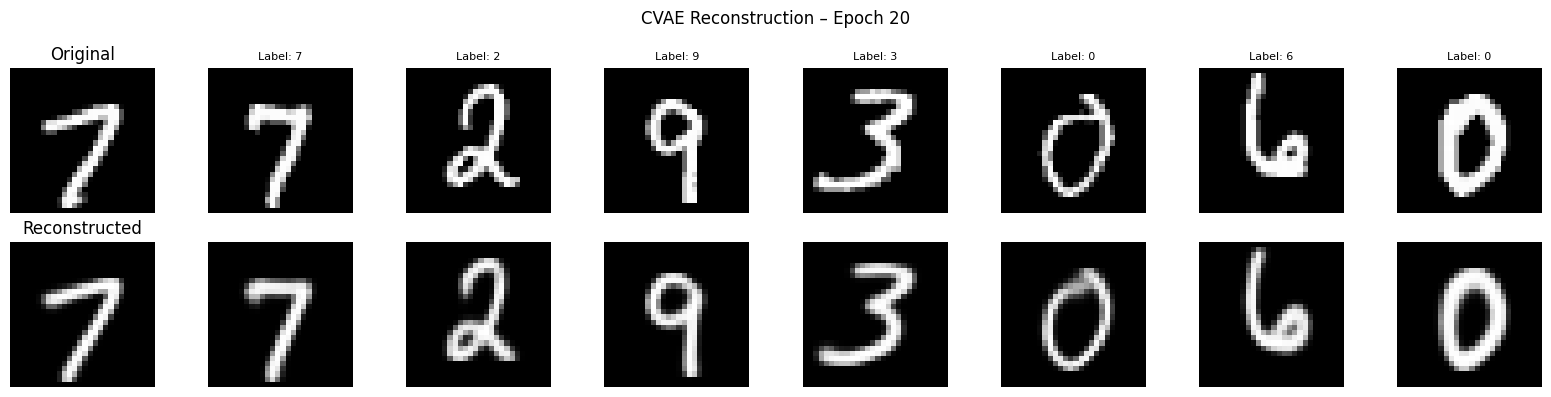

Epoch  21/30 | Train Loss: 92.3565 KL: 21.0970 BCE: 71.2595 | Val Loss: 84.7871 KL: 21.5468 BCE: 63.2404  (нет улучшений 2/5)
Epoch  22/30 | Train Loss: 92.1882 KL: 21.0531 BCE: 71.1351 | Val Loss: 83.8034 KL: 20.8857 BCE: 62.9177  << Лучшая модель сохранена >>
Epoch  23/30 | Train Loss: 92.0398 KL: 21.0152 BCE: 71.0246 | Val Loss: 84.7259 KL: 21.2248 BCE: 63.5011  (нет улучшений 1/5)
Epoch  24/30 | Train Loss: 91.8583 KL: 20.9542 BCE: 70.9041 | Val Loss: 83.7020 KL: 20.6409 BCE: 63.0611  << Лучшая модель сохранена >>
Epoch  25/30 | Train Loss: 91.7571 KL: 20.9307 BCE: 70.8264 | Val Loss: 83.9354 KL: 20.6138 BCE: 63.3216  (нет улучшений 1/5)


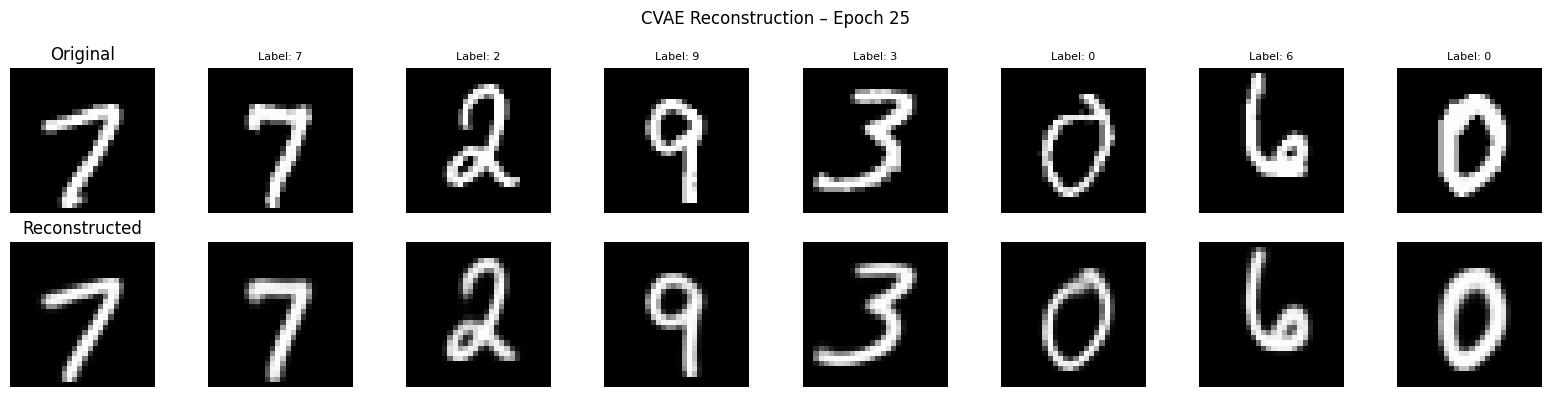

Epoch  26/30 | Train Loss: 91.6245 KL: 20.8981 BCE: 70.7264 | Val Loss: 84.1726 KL: 21.3116 BCE: 62.8611  (нет улучшений 2/5)
Epoch  27/30 | Train Loss: 91.5222 KL: 20.8907 BCE: 70.6315 | Val Loss: 83.5391 KL: 20.3861 BCE: 63.1530  << Лучшая модель сохранена >>
Epoch  28/30 | Train Loss: 91.4254 KL: 20.8871 BCE: 70.5383 | Val Loss: 84.0338 KL: 20.9748 BCE: 63.0590  (нет улучшений 1/5)
Epoch  29/30 | Train Loss: 91.2811 KL: 20.8337 BCE: 70.4474 | Val Loss: 83.4577 KL: 20.6177 BCE: 62.8401  << Лучшая модель сохранена >>
Epoch  30/30 | Train Loss: 91.2036 KL: 20.8121 BCE: 70.3914 | Val Loss: 83.6130 KL: 20.8203 BCE: 62.7927  (нет улучшений 1/5)


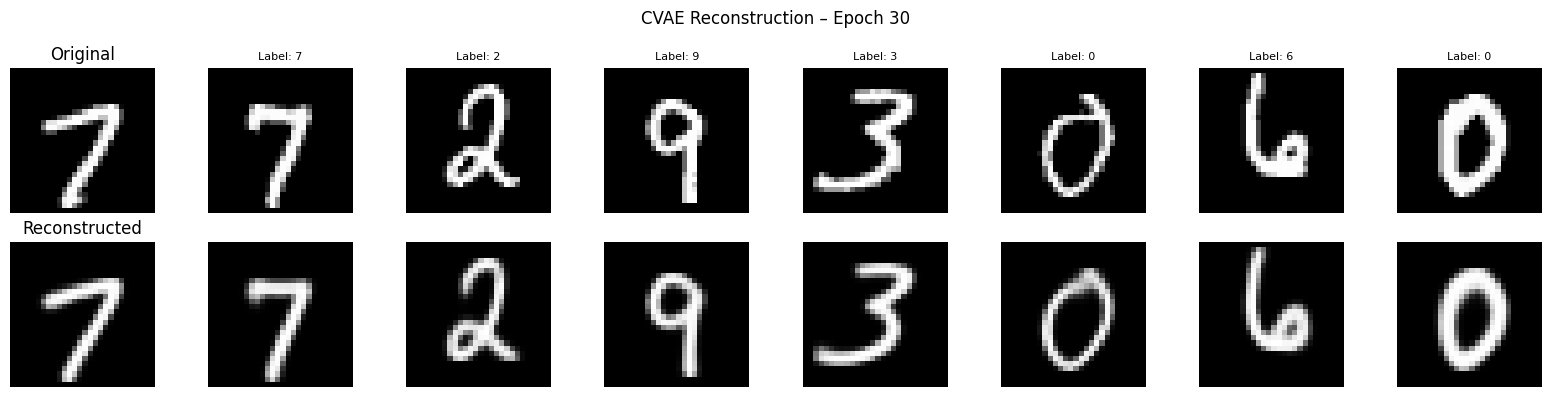

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
cvae = CVAE(latent_dim=32).to(device)
optimizer = torch.optim.Adam(cvae.parameters(), lr=1e-3)

trained_cvae, history = train_cvae(
    model=cvae,
    optimizer=optimizer,
    train_loader=train_loader_mnist,
    val_loader=val_loader_mnist,
    num_epochs=30,
    patience=5,
    device=device
)

### Sampling


Тут мы будем сэмплировать из CVAE. Это прикольнее, чем сэмплировать из простого AE/VAE: тут можно взять один и тот же латентный вектор и попросить CVAE восстановить из него картинки разных классов!
Для MNIST вы можете попросить CVAE восстановить из одного латентного вектора, например, картинки цифры 5 и 7.

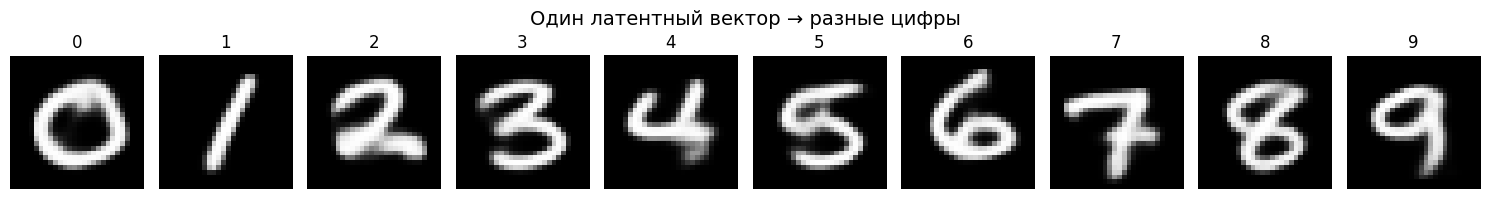

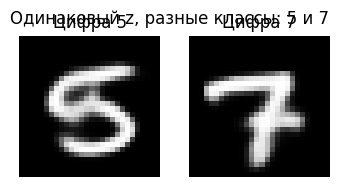

In [ ]:
import torch
import matplotlib.pyplot as plt

# Модель в eval
trained_cvae.eval()
device = next(trained_cvae.parameters()).device

# Фиксируем случайный латентный вектор
latent_dim = trained_cvae.latent_dim
z_fixed = torch.randn(1, latent_dim, device=device)  # [1, latent_dim]

# Создаём тензор со всеми классами от 0 до 9
all_classes = torch.arange(0, 10, device=device).long()  # [10]
z_repeated = z_fixed.repeat(10, 1)                       # [10, latent_dim]

# Декодируем
with torch.no_grad():
    generated = trained_cvae.decode(z_repeated, all_classes)    # [10, 1, 28, 28]

# Переводим в numpy и убираем лишнюю размерность канала
gen_np = generated.cpu().squeeze(1).numpy()              # [10, 28, 28]

# Визуализируем все 10 цифр
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, ax in enumerate(axes):
    ax.imshow(gen_np[i], cmap='gray')
    ax.set_title(f'{i}')
    ax.axis('off')
plt.suptitle('Один латентный вектор → разные цифры', fontsize=14)
plt.tight_layout()
plt.show()

# Отдельно покажем 5 и 7 для наглядности
fig, axes = plt.subplots(1, 2, figsize=(4, 2))
for idx, digit in enumerate([5, 7]):
    axes[idx].imshow(gen_np[digit], cmap='gray')
    axes[idx].set_title(f'Цифра {digit}')
    axes[idx].axis('off')
plt.suptitle('Одинаковый z, разные классы: 5 и 7')
plt.show()

Splendid! Вы великолепны!


### Latent Representations

Давайте посмотрим, как выглядит латентное пространство картинок в CVAE и сравним с картинкой для VAE =)

Опять же, нужно покрасить точки в разные цвета в зависимости от класса.

Собрано 5000 точек, размерность латентного пространства: 32


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


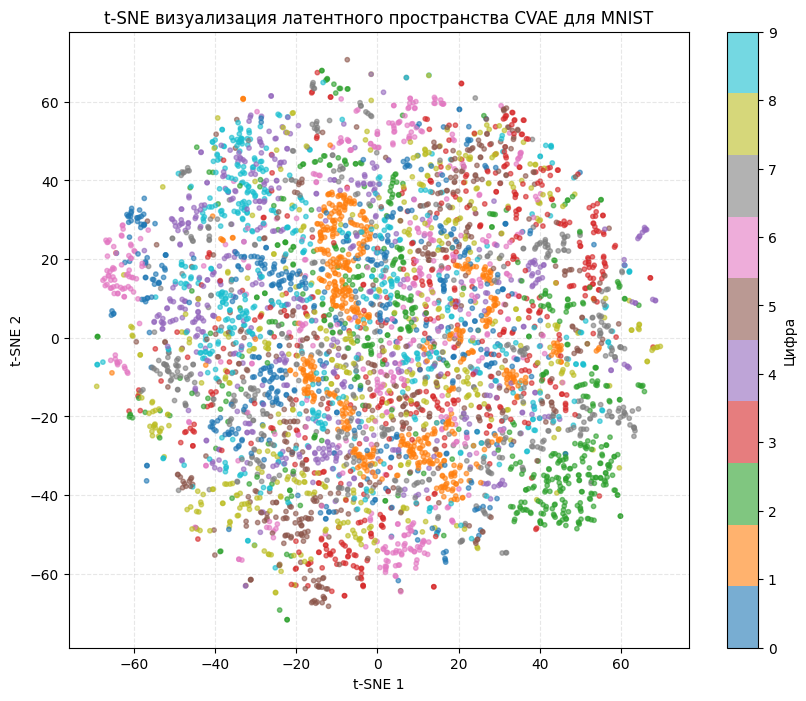

In [ ]:
from sklearn.manifold import TSNE

trained_cvae.eval()
device = next(trained_cvae.parameters()).device

max_samples = 5000
latent_vectors = []
labels = []

with torch.no_grad():
    for x, class_idx in test_loader_mnist:
        x = x.to(device)
        class_idx = class_idx.to(device)
        mu, logvar, _ = trained_cvae.encode(x, class_idx)
        latent_vectors.append(mu.cpu().numpy())
        labels.append(class_idx.cpu().numpy())

        if sum(len(l) for l in labels) >= max_samples:
            break

latent_vectors = np.concatenate(latent_vectors, axis=0)[:max_samples]
labels = np.concatenate(labels, axis=0)[:max_samples]

print(f"Собрано {latent_vectors.shape[0]} точек, размерность латентного пространства: {latent_vectors.shape[1]}")


tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
latent_2d = tsne.fit_transform(latent_vectors)

# Визуализация
plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1],
                      c=labels, cmap='tab10', alpha=0.6, s=10)
plt.colorbar(scatter, ticks=range(10), label='Цифра')
plt.title('t‑SNE визуализация латентного пространства CVAE для MNIST')
plt.xlabel('t‑SNE 1')
plt.ylabel('t‑SNE 2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

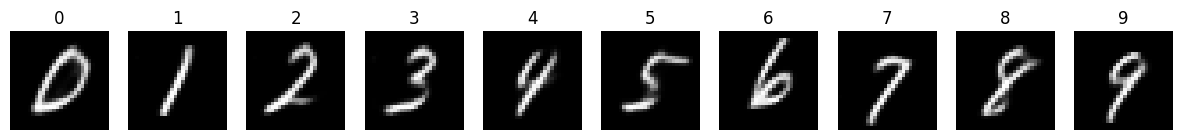

In [ ]:
# Возьмём один случайный z и сгенерируем все 10 цифр
z = torch.randn(1, latent_dim, device=device)
classes = torch.arange(0, 10, device=device).long()
with torch.no_grad():
    imgs = trained_cvae.decode(z.repeat(10, 1), classes)
# Визуализируем: если CVAE обучен, то цифры будут разными и осмысленными
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, ax in enumerate(axes):
    ax.imshow(imgs[i,0].cpu(), cmap='gray')
    ax.set_title(str(i)); ax.axis('off')
plt.show()

Что вы думаете насчет этой картинки? Отличается от картинки для VAE?

Насколько я понимаю, то что все в одной куче это особенности архитектуры из-за того, что информация о классе подается явно, через OHE и в энкодер и в декодер, поэтому так получается. Как видно генерирует все правильно.

# BONUS 1: Denoising (2 балла)



У автоэнкодеров, кроме сжатия и генерации изображений, есть другие практические применения. Про одно из них эта бонусная часть задания.

Автоэнкодеры могут быть использованы для избавления от шума на фотографиях (denoising). Для этого их нужно обучить специальным образом: input картинка будет зашумленной, а выдавать автоэнкодер должен будет картинку без шума.
То есть, loss-функция AE останется той же (MSE между реальной картинкой и выданной), а на вход автоэнкодеру будет подаваться зашумленная картинка.

<a href="https://ibb.co/YbRJ1nZ"><img src="https://i.ibb.co/0QD164t/Screen-Shot-2020-06-04-at-4-49-50-PM.png" alt="Screen-Shot-2020-06-04-at-4-49-50-PM" border="0"></a>

Для этого нужно взять ваш любимый датасет (датасет лиц из первой части этого задания или любой другой) и сделать копию этого датасета с шумом.

В питоне шум можно добавить так:

In [ ]:
noise_factor = 0.5

X_train_noisy = train_tensor + noise_factor * torch.randn_like(train_tensor)
X_val_noisy   = val_tensor + noise_factor * torch.randn_like(val_tensor)

# Обрезаем значения, чтобы они оставались в допустимом диапазоне [0, 1]
X_train_noisy = torch.clamp(X_train_noisy, 0., 1.)
X_val_noisy   = torch.clamp(X_val_noisy, 0., 1.)

# Создаём датасеты, где вход — зашумлённое изображение, цель — чистое
train_dataset_denoise = TensorDataset(X_train_noisy, train_tensor)
val_dataset_denoise   = TensorDataset(X_val_noisy, val_tensor)

batch_size = 64
train_loader_denoise = DataLoader(train_dataset_denoise, batch_size=batch_size, shuffle=True)
val_loader_denoise   = DataLoader(val_dataset_denoise, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader_denoise)}, Val batches: {len(val_loader_denoise)}")

Train batches: 165, Val batches: 42


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

latent_dim = 256

model_denoise = Autoencoder(latent_dim=latent_dim)

model_denoise.load_state_dict(torch.load('/content/drive/MyDrive/Colab Notebooks/DLS-1/auto_enk.pth'))

model_denoise = model_denoise.to(device)

optimizer = torch.optim.Adam(model_denoise.parameters(), lr=1e-3)
criterion = nn.MSELoss()

Epoch   1/30 | Train Loss: 0.006955 | Val Loss: 0.005460  << Лучшая модель сохранена >>


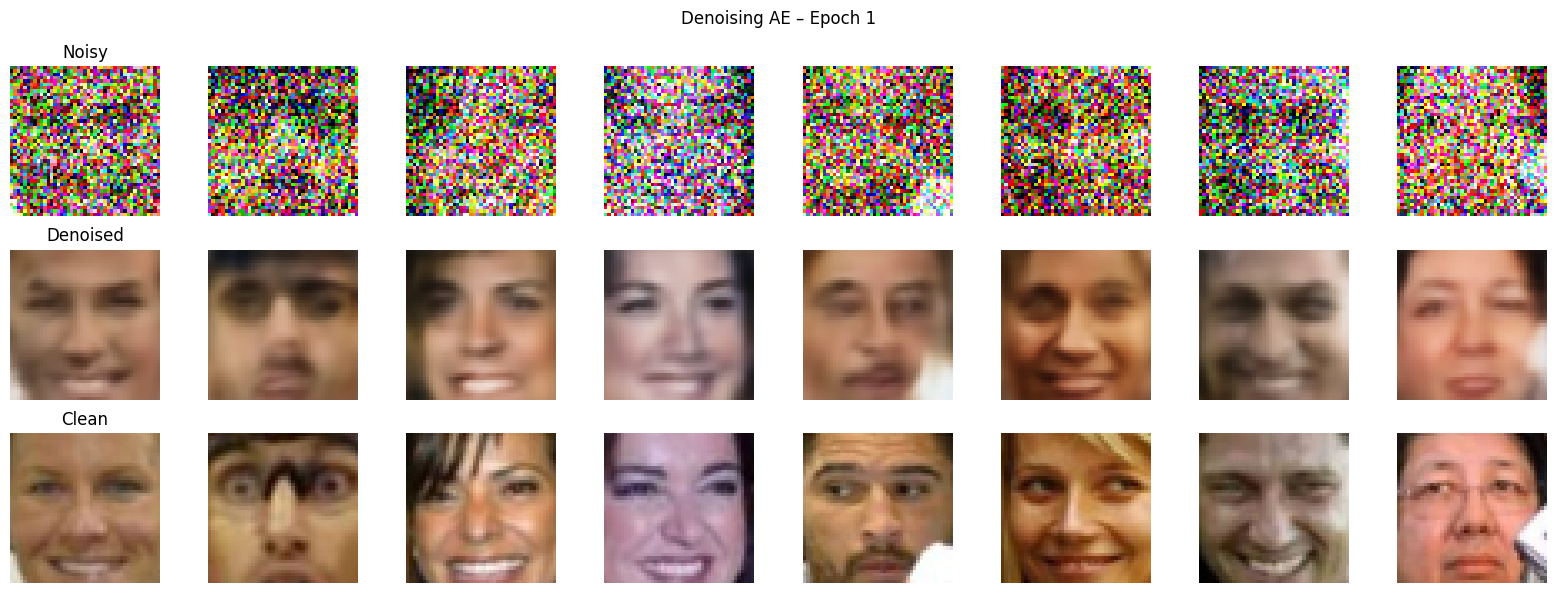

Epoch   2/30 | Train Loss: 0.005042 | Val Loss: 0.005112  << Лучшая модель сохранена >>
Epoch   3/30 | Train Loss: 0.004632 | Val Loss: 0.005049  << Лучшая модель сохранена >>
Epoch   4/30 | Train Loss: 0.004389 | Val Loss: 0.004908  << Лучшая модель сохранена >>
Epoch   5/30 | Train Loss: 0.004193 | Val Loss: 0.005045  (нет улучшений 1/5)


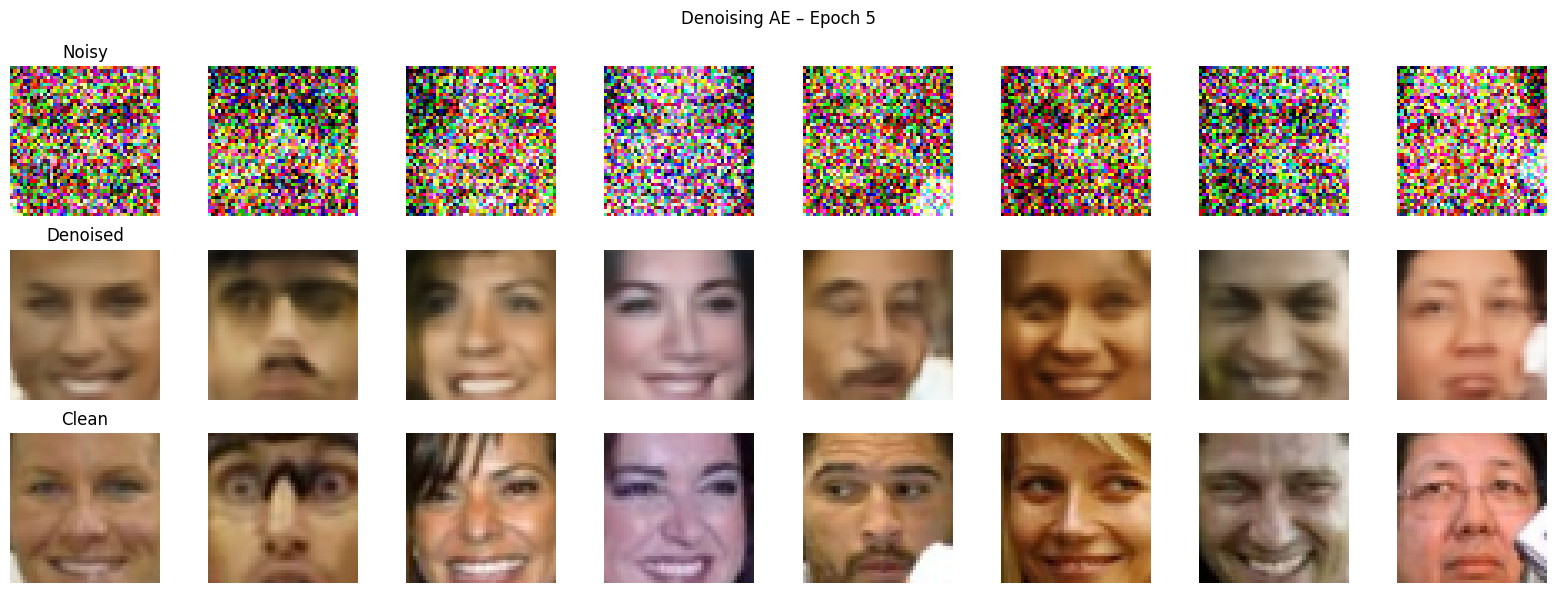

Epoch   6/30 | Train Loss: 0.004055 | Val Loss: 0.004958  (нет улучшений 2/5)
Epoch   7/30 | Train Loss: 0.003858 | Val Loss: 0.004962  (нет улучшений 3/5)
Epoch   8/30 | Train Loss: 0.003719 | Val Loss: 0.005084  (нет улучшений 4/5)
Epoch   9/30 | Train Loss: 0.003613 | Val Loss: 0.005155  (нет улучшений 5/5)

Early stopping на эпохе 9!
Обучение завершено, веса сохранены в denoising_autoencoder.pth


In [ ]:
num_epochs = 30
patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_wts = copy.deepcopy(model_denoise.state_dict())
history = {'train_loss': [], 'val_loss': []}

# Визуализация фиксированного батча для отслеживания прогресса
sample_noisy, sample_clean = next(iter(val_loader_denoise))
sample_noisy = sample_noisy[:8].to(device)
sample_clean = sample_clean[:8].to(device)

for epoch in range(1, num_epochs + 1):
    # Обучение
    model_denoise.train()
    train_loss = 0.0
    for noisy, clean in train_loader_denoise:
        noisy, clean = noisy.to(device), clean.to(device)
        optimizer.zero_grad()
        recon, _ = model_denoise(noisy)          # модель получает зашумлённый вход
        loss = criterion(recon, clean)           # сравниваем с чистым
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * noisy.size(0)
    train_loss /= len(train_loader_denoise.dataset)

    # Валидация
    model_denoise.eval()
    val_loss = 0.0
    with torch.no_grad():
        for noisy, clean in val_loader_denoise:
            noisy, clean = noisy.to(device), clean.to(device)
            recon, _ = model_denoise(noisy)
            loss = criterion(recon, clean)
            val_loss += loss.item() * noisy.size(0)
    val_loss /= len(val_loader_denoise.dataset)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    print(f"Epoch {epoch:3d}/{num_epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}", end="")

    # Ранняя остановка
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_wts = copy.deepcopy(model_denoise.state_dict())
        print("  << Лучшая модель сохранена >>")
    else:
        epochs_no_improve += 1
        print(f"  (нет улучшений {epochs_no_improve}/{patience})")
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping на эпохе {epoch}!")
            break

    # Визуализация каждые 5 эпох
    if epoch % 5 == 0 or epoch == 1:
        model_denoise.eval()
        with torch.no_grad():
            recon_sample, _ = model_denoise(sample_noisy)
        fig, axes = plt.subplots(3, 8, figsize=(16, 6))
        for i in range(8):
            axes[0,i].imshow(sample_noisy[i].cpu().permute(1,2,0).numpy())
            axes[0,i].axis('off')
            axes[1,i].imshow(recon_sample[i].cpu().permute(1,2,0).numpy())
            axes[1,i].axis('off')
            axes[2,i].imshow(sample_clean[i].cpu().permute(1,2,0).numpy())
            axes[2,i].axis('off')
        axes[0,0].set_title('Noisy')
        axes[1,0].set_title('Denoised')
        axes[2,0].set_title('Clean')
        plt.suptitle(f'Denoising AE – Epoch {epoch}')
        plt.tight_layout()
        plt.show()

# Загружаем лучшие веса
model_denoise.load_state_dict(best_model_wts)
torch.save(model_denoise.state_dict(), 'denoising_autoencoder.pth')
print("Обучение завершено, веса сохранены в denoising_autoencoder.pth")

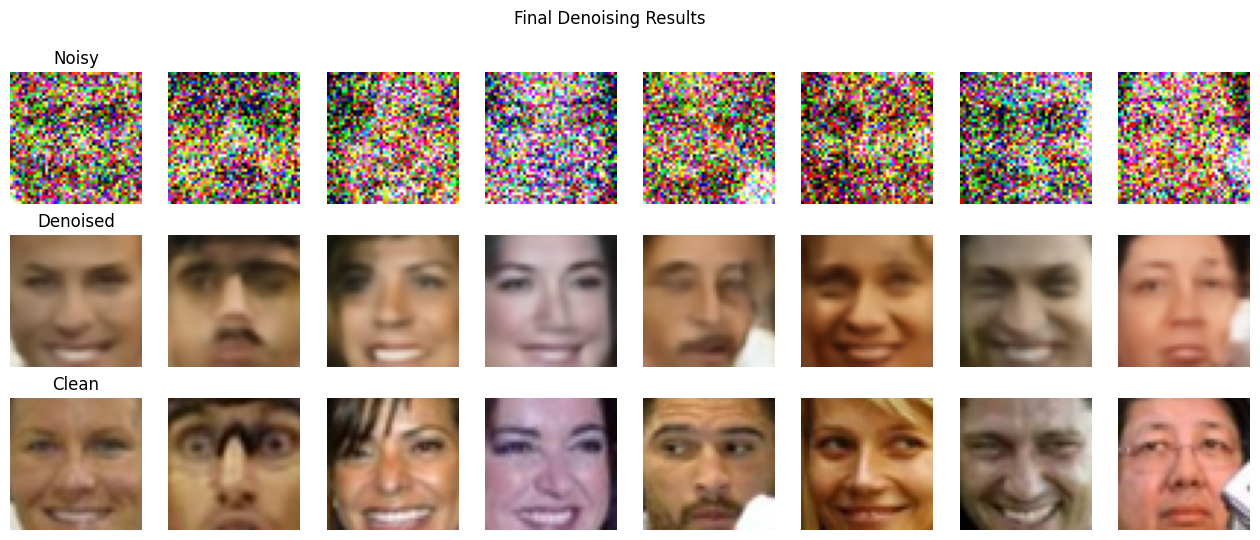

In [ ]:
model_denoise.eval()
with torch.no_grad():
    recon_test, _ = model_denoise(sample_noisy)

fig, axes = plt.subplots(3, 8, figsize=(16, 6))
for i in range(8):
    axes[0,i].imshow(sample_noisy[i].cpu().permute(1,2,0).numpy())
    axes[0,i].axis('off')
    axes[1,i].imshow(recon_test[i].cpu().permute(1,2,0).numpy())
    axes[1,i].axis('off')
    axes[2,i].imshow(sample_clean[i].cpu().permute(1,2,0).numpy())
    axes[2,i].axis('off')
axes[0,0].set_title('Noisy')
axes[1,0].set_title('Denoised')
axes[2,0].set_title('Clean')
plt.suptitle('Final Denoising Results')
plt.show()

# BONUS 2: Image Retrieval (2 балла)



Давайте представим, что весь наш тренировочный датасет -- это большая база данных людей. И вот мы получили картинку лица какого-то человека с уличной камеры наблюдения (у нас это картинка из тестового датасета) и хотим понять, что это за человек. Что нам делать? Правильно -- берем наш VAE, кодируем картинку в латентное представление и ищем среди латентных представлений лиц нашей базы самые ближайшие!

План:

1. Получаем латентные представления всех лиц тренировочного датасета
2. Обучаем на них LSHForest `(sklearn.neighbors.LSHForest)`, например, с `n_estimators=50`
3. Берем картинку из тестового датасета, с помощью VAE получаем ее латентный вектор
4. Ищем с помощью обученного LSHForest ближайшие из латентных представлений тренировочной базы
5. Находим лица тренировочного датасета, которым соответствуют ближайшие латентные представления, визуализируем!

Немного кода вам в помощь: (feel free to delete everything and write your own)

In [ ]:
from sklearn.neighbors import NearestNeighbors

#Вообщем с LSHForest ничего не получилось, она или вообще не работала или вечно вылетали ошибки. Гугл дал мне знать, что вариант выше - это более современная тема.

Латентные векторы train: (10514, 256)
Ищем похожие на изображение под индексом 312


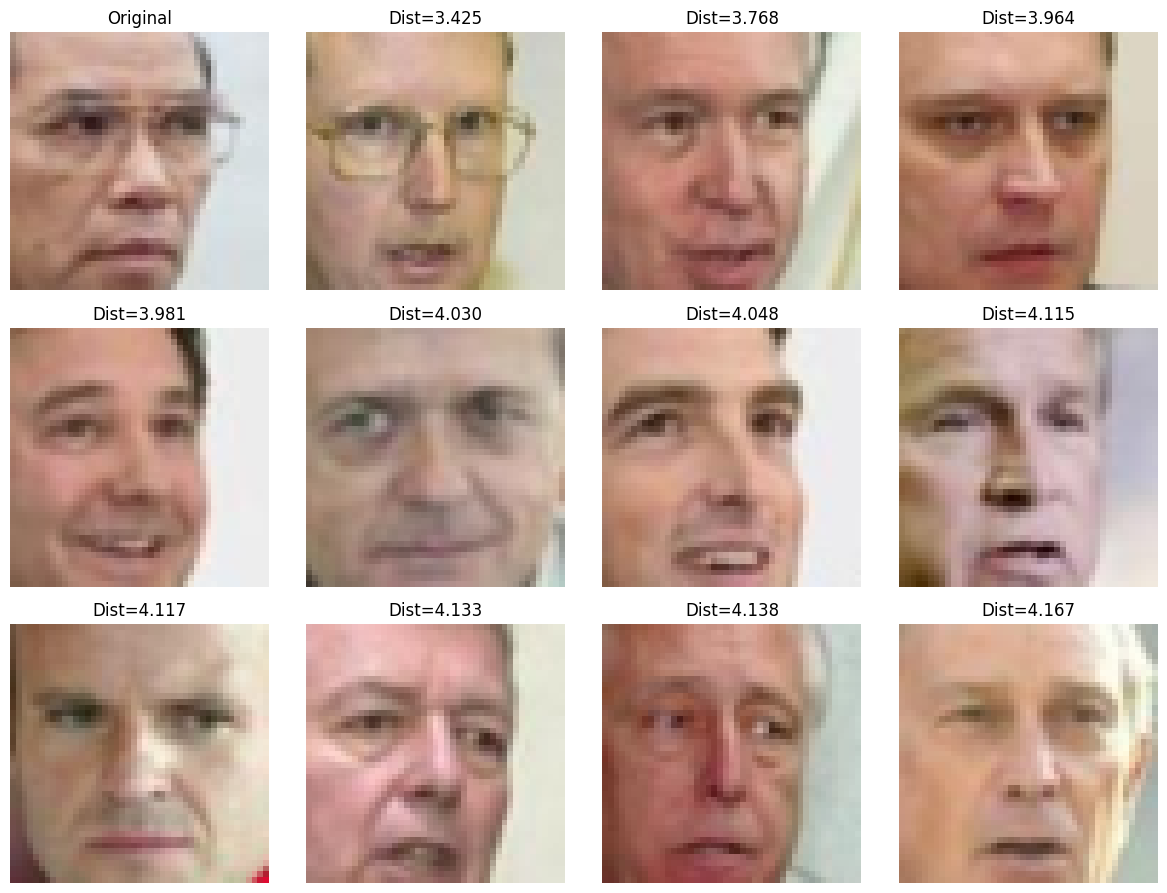

In [ ]:
#Загружаем обученную модель
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
latent_dim = 256
model_retr = Autoencoder(latent_dim=latent_dim)

model_retr.load_state_dict(torch.load('/content/drive/MyDrive/Colab Notebooks/DLS-1/auto_enk.pth'))

model_retr.to(device)
model_retr.eval()

#  Получаем латентные представления всех лиц тренировочного датасета
batch_size = 64
codes = []
with torch.no_grad():
    for i in range(0, len(train_tensor), batch_size):
        batch = train_tensor[i:i+batch_size].to(device)

        _, latent = model_retr(batch)
        codes.append(latent.cpu().numpy())

codes = np.concatenate(codes, axis=0)  # [N_train, latent_dim]
print(f"Латентные векторы train: {codes.shape}")


n_neighbors = 5
nn_model = NearestNeighbors(n_neighbors=n_neighbors, algorithm='auto', n_jobs=-1)
nn_model.fit(codes)

#  Функции для поиска и отображения
def get_similar(image_tensor, n_neighbors=5):

    if image_tensor.dim() == 3:
        image_tensor = image_tensor.unsqueeze(0)  # добавляем batch dimension
    image_tensor = image_tensor.to(device)

    with torch.no_grad():
        _, latent = model_retr(image_tensor)
    code = latent.cpu().numpy()  # [1, latent_dim]

    # Поиск соседей с помощью NearestNeighbors
    distances, idx = nn_model.kneighbors(code, n_neighbors=n_neighbors)

    # Преобразуем в одномерные массивы
    distances = distances[0]
    idx = idx[0]

    # Получаем изображения по индексам из train_tensor
    neighbors = train_tensor[idx]
    return distances, neighbors

def show_similar(image_tensor, n_neighbors=11):

    distances, neighbors = get_similar(image_tensor, n_neighbors=n_neighbors)

    # Отображаем сетку: оригинал + соседи
    n_cols = 4
    n_rows = (n_neighbors + 1) // n_cols + 1
    plt.figure(figsize=[12, 3 * n_rows])

    # Оригинал
    plt.subplot(n_rows, n_cols, 1)
    img_np = image_tensor.cpu().numpy()
    if img_np.shape[0] == 3:  # C, H, W -> H, W, C
        img_np = np.transpose(img_np, (1, 2, 0))
    plt.imshow(np.clip(img_np, 0, 1))
    plt.title("Original")
    plt.axis('off')

    # Соседи
    for i in range(n_neighbors):
        plt.subplot(n_rows, n_cols, i + 2)
        neighbor_np = neighbors[i].cpu().numpy().transpose(1, 2, 0)
        plt.imshow(np.clip(neighbor_np, 0, 1))
        plt.title(f"Dist={distances[i]:.3f}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Пример использования
sample_idx = np.random.randint(0, len(val_tensor))
test_image = val_tensor[sample_idx]  # [3, 45, 45]

print(f"Ищем похожие на изображение под индексом {sample_idx}")
show_similar(test_image, n_neighbors=11)